## CIC + FIR Compensador

Este modelo implementa uma cadeia de filtragem para converter o sinal PDM de 1 bit a 4,8 MHz em uma saída digital multibit a 300 kHz. A arquitetura é composta por um filtro CIC decimador, com N=4, R=16 e M=1, seguido por um FIR compensador de 65 taps.

O CIC realiza a decimação de 4,8 MHz para 300 kHz, porém apresenta uma queda de ganho (*droop*) na banda útil de **20 a 80 kHz**. Para corrigir esse efeito, a resposta desejada do FIR é definida aproximadamente como o inverso da resposta do CIC nessa região:

$$
H_{FIR}(f)\approx\frac{1}{H_{CIC}(f)}
$$

Dessa forma, busca-se obter:

$$
H_{TOTAL}(f)=H_{CIC}(f)H_{FIR}(f)\approx1
$$

na banda útil. Os coeficientes do FIR são obtidos pelo método de mínimos quadrados (FIRLS), permitindo simultaneamente compensar o droop e realizar a filtragem passa-baixa.

Para aproximar o modelo da futura implementação em hardware, utiliza-se aritmética de ponto fixo, com CIC de 17 bits, coeficientes FIR de 16 bits Q1.15, acumulador FIR de 34 bits e saída signed de 19 bits.


# Resumo dos parâmetros — CIC + FIR compensador

$$
\begin{aligned}
f_{PDM} &= 4,8\text{ MHz}\\
f_{out} &= 300\text{ kHz}\\
N_{CIC} &= 4\\
R &= 16\\
M &= 1\\
B_{CIC} &= 17\text{ bits}\\
N_{FIR} &= 65\text{ taps}\\
B_{coef} &= 16\text{ bits (Q1.15)}\\
B_{acc} &= 34\text{ bits}\\
B_{out} &= 19\text{ bits signed}\\
f_{útil} &= 20\text{--}80\text{ kHz}
\end{aligned}
$$


In [ ]:
# ============================================================
# CÉLULA 1 - BIBLIOTECAS
# ============================================================

import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


In [ ]:
# ============================================================
# CÉLULA 2 - PARÂMETROS OFICIAIS
# ============================================================

# ------------------------------------------------------------
# Taxas de amostragem
# ------------------------------------------------------------

FS_PDM = 4.8e6

R = 16

FS_OUT = FS_PDM / R


# ------------------------------------------------------------
# CIC
# ------------------------------------------------------------

CIC_N = 4
CIC_R = 16
CIC_M = 1

BITS_CIC = 17


# ------------------------------------------------------------
# FIR
# ------------------------------------------------------------

FIR_TAPS = 65

BITS_COEF = 16
FRAC_COEF = 15

BITS_ACC_FIR = 34
BITS_SAIDA = 19


# ------------------------------------------------------------
# Banda de interesse
# ------------------------------------------------------------

F_UTIL_MIN = 20e3
F_UTIL_MAX = 80e3


print("=== GOLDEN MODEL ===")

print(
    f"FS_PDM = {FS_PDM/1e6:.3f} MHz"
)

print(
    f"FS_OUT = {FS_OUT/1e3:.3f} kHz"
)

print()

print(
    f"CIC: N={CIC_N}, "
    f"R={CIC_R}, "
    f"M={CIC_M}"
)

print(
    f"CIC word length = "
    f"{BITS_CIC} bits"
)

print()

print(
    f"FIR = {FIR_TAPS} taps"
)

print(
    f"Coeficientes = "
    f"{BITS_COEF} bits Q1.{FRAC_COEF}"
)

print(
    f"Acumulador FIR = "
    f"{BITS_ACC_FIR} bits"
)

print(
    f"Saída final = "
    f"{BITS_SAIDA} bits"
)

print()

print(
    f"Faixa saída signed = "
    f"[{-2**(BITS_SAIDA-1)}, "
    f"{2**(BITS_SAIDA-1)-1}]"
)

=== GOLDEN MODEL ===
FS_PDM = 4.800 MHz
FS_OUT = 300.000 kHz

CIC: N=4, R=16, M=1
CIC word length = 17 bits

FIR = 65 taps
Coeficientes = 16 bits Q1.15
Acumulador FIR = 34 bits
Saída final = 19 bits

Faixa saída signed = [-262144, 262143]


In [ ]:
# ============================================================
# CÉLULA 3 - ARITMÉTICA SIGNED
# ============================================================

def wrap_signed(x, bits):
    """
    Wrap modular em complemento de dois.
    """

    modulo = 2 ** bits
    metade = 2 ** (bits - 1)

    return (
        (int(x) + metade) % modulo
    ) - metade


def sat_signed(x, bits):
    """
    Saturação signed.
    """

    minimo = -(2 ** (bits - 1))
    maximo =  (2 ** (bits - 1)) - 1

    return min(
        max(int(x), minimo),
        maximo
    )


def round_shift_signed(x, shift):
    """
    Divide por 2**shift usando
    arredondamento simétrico.
    """

    x = int(x)

    metade = 1 << (shift - 1)

    if x >= 0:

        return (
            x + metade
        ) >> shift

    else:

        return -(
            ((-x) + metade)
            >> shift
        )

In [ ]:
# ============================================================
# CÉLULA 4 - TESTES DAS FUNÇÕES AUXILIARES
# ============================================================

print("=== WRAP 17 BITS ===")

valores_wrap = [
    65535,
    65536,
    -65536,
    -65537
]

for x in valores_wrap:

    print(
        f"{x:7d} -> "
        f"{wrap_signed(x, 17):7d}"
    )


print()

print("=== ROUND SHIFT ===")

valores_round = [
    32768,
    49152,
    -32768,
    -49152
]

for x in valores_round:

    print(
        f"{x:7d} >>15 arred. = "
        f"{round_shift_signed(x, 15)}"
    )

=== WRAP 17 BITS ===
  65535 ->   65535
  65536 ->  -65536
 -65536 ->  -65536
 -65537 ->   65535

=== ROUND SHIFT ===
  32768 >>15 arred. = 1
  49152 >>15 arred. = 2
 -32768 >>15 arred. = -1
 -49152 >>15 arred. = -2


In [ ]:
# ============================================================
# CÉLULA 5 - CIC FIXED-POINT DEFINITIVO
# ============================================================

def cic_fixed_point(pdm_bits):
    """
    CIC decimador definitivo do Golden Model.

    Arquitetura:
        N = 4
        R = 16
        M = 1
        word length = 17 bits signed

    Entrada:
        pdm_bits -> vetor contendo somente 0 e 1

    Conversão interna:
        0 -> -1
        1 -> +1

    Saída:
        vetor signed de 17 bits
        taxa = FS_PDM / R = 300 kHz

    Observação:
        Aritmética dos integradores e combs usa
        wrap modular em complemento de dois.
    """

    pdm_bits = np.asarray(
        pdm_bits,
        dtype=np.int8
    )

    # Verificação da entrada
    if not np.all(
        (pdm_bits == 0) |
        (pdm_bits == 1)
    ):
        raise ValueError(
            "A entrada PDM deve conter somente 0 e 1."
        )

    # Estados dos N integradores
    integradores = [0] * CIC_N

    # Memórias dos N combs
    # Como M = 1, cada estágio precisa de um atraso.
    comb_delay = [0] * CIC_N

    saida = []

    # ========================================================
    # PROCESSAMENTO AMOSTRA A AMOSTRA
    # ========================================================

    for n, bit in enumerate(pdm_bits):

        # ----------------------------------------------------
        # PDM: 0 -> -1 / 1 -> +1
        # ----------------------------------------------------

        x = 1 if bit == 1 else -1

        # ----------------------------------------------------
        # N INTEGRADORES
        # Operam na taxa de 4,8 MHz
        # ----------------------------------------------------

        for estágio in range(CIC_N):

            if estágio == 0:
                entrada_estagio = x
            else:
                entrada_estagio = integradores[estágio - 1]

            soma = (
                integradores[estágio]
                +
                entrada_estagio
            )

            integradores[estágio] = wrap_signed(
                soma,
                BITS_CIC
            )

        # ----------------------------------------------------
        # DECIMAÇÃO POR R
        #
        # Produz uma amostra após cada grupo de 16 bits PDM.
        # ----------------------------------------------------

        if (n + 1) % CIC_R != 0:
            continue

        y = integradores[-1]

        # ----------------------------------------------------
        # N COMBS
        # Operam na taxa reduzida de 300 kHz
        # ----------------------------------------------------

        for estágio in range(CIC_N):

            atraso = comb_delay[estágio]

            diferenca = (
                y - atraso
            )

            # Guarda a entrada atual para a próxima amostra
            comb_delay[estágio] = y

            # Saída do estágio com wrap de 17 bits
            y = wrap_signed(
                diferenca,
                BITS_CIC
            )

        saida.append(y)

    return np.asarray(
        saida,
        dtype=np.int64
    )

In [ ]:
# ============================================================
# CÉLULA 6 - TESTE DA RAZÃO DE DECIMAÇÃO
# ============================================================

# Padrão PDM simples 101010...
N_TEST = 9600

pdm_test = np.tile(
    [1, 0],
    N_TEST // 2
).astype(np.int8)

cic_test = cic_fixed_point(
    pdm_test
)

print("=== TESTE CIC ===")

print(
    f"Entrada PDM = "
    f"{len(pdm_test)} bits"
)

print(
    f"Saída CIC = "
    f"{len(cic_test)} amostras"
)

print(
    f"Razão observada = "
    f"{len(pdm_test) / len(cic_test):.1f}"
)

assert (
    len(cic_test)
    ==
    len(pdm_test) // CIC_R
)

print(
    "Teste de decimação: OK"
)

=== TESTE CIC ===
Entrada PDM = 9600 bits
Saída CIC = 600 amostras
Razão observada = 16.0
Teste de decimação: OK


In [ ]:
# ============================================================
# CÉLULA 7 - VERIFICAÇÃO DA FAIXA DO CIC
# ============================================================

CIC_MIN = -(2 ** (BITS_CIC - 1))
CIC_MAX =  (2 ** (BITS_CIC - 1)) - 1

min_test = int(
    np.min(cic_test)
)

max_test = int(
    np.max(cic_test)
)

print("=== FAIXA DA SAÍDA CIC ===")

print(
    f"Faixa permitida = "
    f"[{CIC_MIN}, {CIC_MAX}]"
)

print(
    f"Mínimo observado = "
    f"{min_test}"
)

print(
    f"Máximo observado = "
    f"{max_test}"
)

assert min_test >= CIC_MIN
assert max_test <= CIC_MAX

print(
    "Teste de largura do CIC: OK"
)

=== FAIXA DA SAÍDA CIC ===
Faixa permitida = [-65536, 65535]
Mínimo observado = 0
Máximo observado = 1352
Teste de largura do CIC: OK


In [ ]:
# ============================================================
# CÉLULA 8 - COEFICIENTES FIR DEFINITIVOS
# ============================================================

# FIR compensador:
# 65 taps
# coeficientes signed de 16 bits
# escala Q1.15
#
# Estes valores são considerados CONSTANTES do Golden Model.

FIR_COEF_Q15 = np.array([
      -6,     -2,     14,    -11,    -22,
      43,     -4,    -80,     82,     56,
    -196,     81,    218,   -330,    -28,
     515,   -404,   -389,    869,   -207,
   -1010,   1065,    394,  -1849,    920,
    1915,  -2661,   -709,   4553,  -2307,
   -6823,  10412,  24614,  10412,  -6823,
   -2307,   4553,   -709,  -2661,   1915,
     920,  -1849,    394,   1065,  -1010,
    -207,    869,   -389,   -404,    515,
     -28,   -330,    218,     81,   -196,
      56,     82,    -80,     -4,     43,
     -22,    -11,     14,     -2,     -6
], dtype=np.int64)

assert len(FIR_COEF_Q15) == FIR_TAPS

print(
    f"Número de coeficientes = "
    f"{len(FIR_COEF_Q15)}"
)

print(
    f"Menor coeficiente = "
    f"{np.min(FIR_COEF_Q15)}"
)

print(
    f"Maior coeficiente = "
    f"{np.max(FIR_COEF_Q15)}"
)

print(
    "Coeficientes FIR carregados."
)

Número de coeficientes = 65
Menor coeficiente = -6823
Maior coeficiente = 24614
Coeficientes FIR carregados.


In [ ]:
# ============================================================
# CÉLULA 9 - VERIFICAÇÃO DA SIMETRIA
# ============================================================

simetrico = np.array_equal(
    FIR_COEF_Q15,
    FIR_COEF_Q15[::-1]
)

print(
    f"FIR simétrico = "
    f"{simetrico}"
)

assert simetrico

print(
    "Teste de simetria: OK"
)

FIR simétrico = True
Teste de simetria: OK


In [ ]:
# ============================================================
# CÉLULA 10 - COEFICIENTES NORMALIZADOS
# ============================================================

FIR_COEF_FLOAT = (
    FIR_COEF_Q15.astype(float)
    /
    (2 ** FRAC_COEF)
)

print("=== COEFICIENTES ===")

print(
    f"Soma = "
    f"{np.sum(FIR_COEF_FLOAT):.8f}"
)

print(
    f"Soma dos módulos = "
    f"{np.sum(np.abs(FIR_COEF_FLOAT)):.8f}"
)

print(
    f"Maior |h| = "
    f"{np.max(np.abs(FIR_COEF_FLOAT)):.8f}"
)

=== COEFICIENTES ===
Soma = 1.00134277
Soma dos módulos = 3.08117676
Maior |h| = 0.75115967


In [ ]:
# ============================================================
# CÉLULA 11 - FIR FIXED-POINT DEFINITIVO
# ============================================================

def fir_fixed_point(x):
    """
    FIR definitivo do Golden Model.

    Entrada:
        signed de 17 bits

    Coeficientes:
        65 taps
        signed 16 bits
        Q1.15

    Acumulador:
        34 bits signed

    Saída:
        remoção da escala Q15 por arredondamento
        largura final considerada: 19 bits
    """

    x = np.asarray(
        x,
        dtype=np.int64
    )

    y = np.zeros(
        len(x),
        dtype=np.int64
    )

    for n in range(len(x)):

        acc = 0

        for k in range(FIR_TAPS):

            idx = n - k

            if idx >= 0:

                produto = (
                    int(x[idx])
                    *
                    int(FIR_COEF_Q15[k])
                )

                acc += produto

        # Acumulador de 34 bits
        acc = sat_signed(
            acc,
            BITS_ACC_FIR
        )

        # Retira Q15 com arredondamento simétrico
        y_temp = round_shift_signed(
            acc,
            FRAC_COEF
        )

        # Saída definitiva de 19 bits
        y[n] = sat_signed(
            y_temp,
            BITS_SAIDA
        )

    return y

In [ ]:
# ============================================================
# CÉLULA 12 - TESTE DO FIR
# ============================================================

fir_test = fir_fixed_point(
    cic_test
)

OUT_MIN = -(2 ** (BITS_SAIDA - 1))
OUT_MAX =  (2 ** (BITS_SAIDA - 1)) - 1

print("=== TESTE FIR ===")

print(
    f"Número de amostras de entrada = "
    f"{len(cic_test)}"
)

print(
    f"Número de amostras de saída = "
    f"{len(fir_test)}"
)

print(
    f"Saída mínima = "
    f"{np.min(fir_test)}"
)

print(
    f"Saída máxima = "
    f"{np.max(fir_test)}"
)

assert len(fir_test) == len(cic_test)

assert np.min(fir_test) >= OUT_MIN
assert np.max(fir_test) <= OUT_MAX

print(
    "Teste estrutural do FIR: OK"
)

=== TESTE FIR ===
Número de amostras de entrada = 600
Número de amostras de saída = 600
Saída mínima = -233
Saída máxima = 1237
Teste estrutural do FIR: OK


In [ ]:
# ============================================================
# CÉLULA 13 - GOLDEN MODEL COMPLETO
# ============================================================

def golden_model(pdm_bits):
    """
    Golden Model oficial da cadeia digital.

    Entrada:
        pdm_bits
        vetor contendo somente 0 e 1
        taxa = 4,8 MHz

    Processamento:
        CIC:
            N = 4
            R = 16
            M = 1
            17 bits signed

        FIR:
            65 taps
            coeficientes Q1.15
            acumulador de 34 bits
            saída de 19 bits

    Saída:
        vetor signed de 19 bits
        taxa = 300 kHz
    """

    # CIC
    cic_out = cic_fixed_point(
        pdm_bits
    )

    # FIR
    fir_out = fir_fixed_point(
        cic_out
    )

    return fir_out

In [ ]:
# ============================================================
# CÉLULA 14 - TESTE ESTRUTURAL DO GOLDEN MODEL
# ============================================================

golden_test = golden_model(
    pdm_test
)

print("=== GOLDEN MODEL ===")

print(
    f"Entrada PDM = "
    f"{len(pdm_test)} bits"
)

print(
    f"Saída final = "
    f"{len(golden_test)} amostras"
)

print(
    f"Razão entrada/saída = "
    f"{len(pdm_test) / len(golden_test):.1f}"
)

print(
    f"Saída mínima = "
    f"{np.min(golden_test)}"
)

print(
    f"Saída máxima = "
    f"{np.max(golden_test)}"
)

assert (
    len(golden_test)
    ==
    len(pdm_test) // CIC_R
)

assert (
    np.min(golden_test)
    >= OUT_MIN
)

assert (
    np.max(golden_test)
    <= OUT_MAX
)

print(
    "Golden Model estrutural: OK"
)

=== GOLDEN MODEL ===
Entrada PDM = 9600 bits
Saída final = 600 amostras
Razão entrada/saída = 16.0
Saída mínima = -233
Saída máxima = 1237
Golden Model estrutural: OK


In [ ]:
# ============================================================
# CÉLULA 15 - GERADOR PDM PARA OS TESTES
# ============================================================

def sigma_delta_1bit(x):
    """
    Modulador sigma-delta de primeira ordem.

    Uso:
        somente geração de estímulos PDM.

    Saída:
        0 ou 1
    """

    x = np.asarray(
        x,
        dtype=float
    )

    pdm = np.zeros(
        len(x),
        dtype=np.int8
    )

    integrador = 0.0
    y_prev = 0.0

    for n in range(len(x)):

        integrador += (
            x[n] - y_prev
        )

        if integrador >= 0:

            y = 1.0
            pdm[n] = 1

        else:

            y = -1.0
            pdm[n] = 0

        y_prev = y

    return pdm

In [ ]:
# ============================================================
# CÉLULA 16 - GERADOR DE TESTE SENOIDAL
# ============================================================

def gerar_pdm_seno(
    freq,
    amplitude=0.8,
    duracao=0.002
):
    """
    Gera:
        senoide normalizada
        seguida de modulação sigma-delta 1-bit.
    """

    t = np.arange(
        0,
        duracao,
        1 / FS_PDM
    )

    sinal = (
        amplitude *
        np.sin(
            2 * np.pi *
            freq *
            t
        )
    )

    pdm = sigma_delta_1bit(
        sinal
    )

    return t, sinal, pdm

In [ ]:
# ============================================================
# CÉLULA 17 - TESTE FUNCIONAL DE 50 kHz
# ============================================================

t_50k, sinal_50k, pdm_50k = gerar_pdm_seno(
    freq=50e3,
    amplitude=0.8,
    duracao=0.002
)

y_50k = golden_model(
    pdm_50k
)

print("=== TESTE 50 kHz ===")

print(
    f"Entrada analógica simulada = "
    f"{len(sinal_50k)} amostras"
)

print(
    f"PDM = "
    f"{len(pdm_50k)} bits"
)

print(
    f"Saída Golden = "
    f"{len(y_50k)} amostras"
)

print(
    f"Saída mínima = "
    f"{np.min(y_50k)}"
)

print(
    f"Saída máxima = "
    f"{np.max(y_50k)}"
)

print(
    f"Valores únicos do PDM = "
    f"{np.unique(pdm_50k)}"
)

=== TESTE 50 kHz ===
Entrada analógica simulada = 9600 amostras
PDM = 9600 bits
Saída Golden = 600 amostras
Saída mínima = -48389
Saída máxima = 47021
Valores únicos do PDM = [0 1]


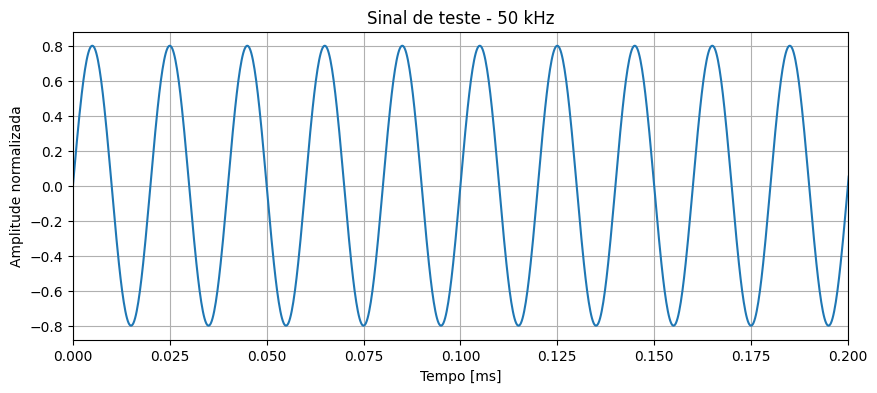

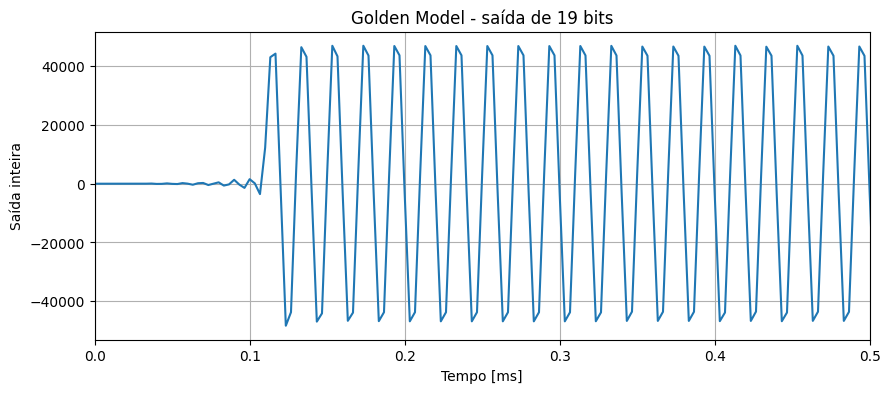

In [ ]:
# ============================================================
# CÉLULA 18 - VISUALIZAÇÃO DO TESTE
# ============================================================

t_out_50k = (
    np.arange(
        len(y_50k)
    )
    /
    FS_OUT
)

plt.figure(figsize=(10, 4))

plt.plot(
    t_50k * 1e3,
    sinal_50k
)

plt.xlim(0, 0.2)

plt.xlabel("Tempo [ms]")
plt.ylabel("Amplitude normalizada")

plt.title(
    "Sinal de teste - 50 kHz"
)

plt.grid()
plt.show()


plt.figure(figsize=(10, 4))

plt.plot(
    t_out_50k * 1e3,
    y_50k
)

plt.xlim(0, 0.5)

plt.xlabel("Tempo [ms]")
plt.ylabel("Saída inteira")

plt.title(
    "Golden Model - saída de 19 bits"
)

plt.grid()
plt.show()

In [ ]:
# ============================================================
# CÉLULA 19 - SUÍTE DE SENOIDES
# ============================================================

frequencias_teste = [
    10e3,
    30e3,
    50e3,
    80e3
]

resultados_seno = {}

for freq in frequencias_teste:

    t, sinal, pdm = gerar_pdm_seno(
        freq=freq,
        amplitude=0.8,
        duracao=0.002
    )

    y = golden_model(
        pdm
    )

    resultados_seno[freq] = {
        "t": t,
        "sinal": sinal,
        "pdm": pdm,
        "y": y
    }


print(
    "Freq. | PDM | Saída | mínimo | máximo"
)

print("-" * 55)

for freq, dados in resultados_seno.items():

    print(
        f"{freq/1e3:5.0f} kHz | "
        f"{len(dados['pdm']):4d} | "
        f"{len(dados['y']):5d} | "
        f"{np.min(dados['y']):7d} | "
        f"{np.max(dados['y']):7d}"
    )

Freq. | PDM | Saída | mínimo | máximo
-------------------------------------------------------
   10 kHz | 9600 |   600 |  -52505 |   52589
   30 kHz | 9600 |   600 |  -51179 |   50699
   50 kHz | 9600 |   600 |  -48389 |   47021
   80 kHz | 9600 |   600 |  -53745 |   52370


In [ ]:
# ============================================================
# CÉLULA 20 - VERIFICAÇÃO AUTOMÁTICA DA SUÍTE
# ============================================================

print("=== VERIFICAÇÃO DOS TESTES ===")

for freq, dados in resultados_seno.items():

    pdm = dados["pdm"]
    y = dados["y"]

    pdm_valido = np.all(
        np.isin(
            pdm,
            [0, 1]
        )
    )

    decimacao_ok = (
        len(pdm)
        ==
        len(y) * CIC_R
    )

    saida_ok = (
        np.min(y) >= OUT_MIN
        and
        np.max(y) <= OUT_MAX
    )

    print(
        f"{freq/1e3:5.0f} kHz | "
        f"PDM: {'OK' if pdm_valido else 'ERRO'} | "
        f"R=16: {'OK' if decimacao_ok else 'ERRO'} | "
        f"19 bits: {'OK' if saida_ok else 'OVERFLOW'}"
    )

=== VERIFICAÇÃO DOS TESTES ===
   10 kHz | PDM: OK | R=16: OK | 19 bits: OK
   30 kHz | PDM: OK | R=16: OK | 19 bits: OK
   50 kHz | PDM: OK | R=16: OK | 19 bits: OK
   80 kHz | PDM: OK | R=16: OK | 19 bits: OK


In [ ]:
# ============================================================
# CÉLULA 21 - TESTE DE 50 kHz + RUÍDO
# ============================================================

np.random.seed(1234)

duracao_ruido = 0.002

t_ruido = np.arange(
    0,
    duracao_ruido,
    1 / FS_PDM
)

sinal_50k_ruido = (
    0.7 *
    np.sin(
        2 * np.pi *
        50e3 *
        t_ruido
    )
)

ruido = (
    0.08 *
    np.random.randn(
        len(t_ruido)
    )
)

sinal_50k_ruido = (
    sinal_50k_ruido +
    ruido
)

# Limita entrada do sigma-delta
sinal_50k_ruido = np.clip(
    sinal_50k_ruido,
    -1.0,
    1.0
)

pdm_50k_ruido = sigma_delta_1bit(
    sinal_50k_ruido
)

y_50k_ruido = golden_model(
    pdm_50k_ruido
)

print("=== TESTE 50 kHz + RUÍDO ===")

print(
    f"PDM = {len(pdm_50k_ruido)} bits"
)

print(
    f"Saída = {len(y_50k_ruido)} amostras"
)

print(
    f"Saída mínima = "
    f"{np.min(y_50k_ruido)}"
)

print(
    f"Saída máxima = "
    f"{np.max(y_50k_ruido)}"
)

print(
    f"RMS do ruído = "
    f"{np.sqrt(np.mean(ruido**2)):.6f}"
)

assert np.all(
    np.isin(
        pdm_50k_ruido,
        [0, 1]
    )
)

assert (
    len(pdm_50k_ruido)
    ==
    len(y_50k_ruido) * CIC_R
)

assert (
    np.min(y_50k_ruido) >= OUT_MIN
    and
    np.max(y_50k_ruido) <= OUT_MAX
)

print(
    "Teste 50 kHz + ruído: OK"
)

=== TESTE 50 kHz + RUÍDO ===
PDM = 9600 bits
Saída = 600 amostras
Saída mínima = -44353
Saída máxima = 44383
RMS do ruído = 0.079692
Teste 50 kHz + ruído: OK


In [ ]:
# ============================================================
# CÉLULA 22 - BURST DE 50 kHz + RUÍDO
# ============================================================

np.random.seed(5678)

duracao_burst = 0.002

t_burst = np.arange(
    0,
    duracao_burst,
    1 / FS_PDM
)

inicio_burst = 0.0005
fim_burst = 0.0015

janela_burst = (
    (t_burst >= inicio_burst) &
    (t_burst < fim_burst)
).astype(float)

portadora_burst = np.sin(
    2 * np.pi *
    50e3 *
    t_burst
)

burst_limpo = (
    0.7 *
    janela_burst *
    portadora_burst
)

ruido_burst = (
    0.08 *
    np.random.randn(
        len(t_burst)
    )
)

sinal_burst = (
    burst_limpo +
    ruido_burst
)

sinal_burst = np.clip(
    sinal_burst,
    -1.0,
    1.0
)

pdm_burst = sigma_delta_1bit(
    sinal_burst
)

y_burst = golden_model(
    pdm_burst
)

print("=== TESTE BURST + RUÍDO ===")

print(
    f"PDM = {len(pdm_burst)} bits"
)

print(
    f"Saída = {len(y_burst)} amostras"
)

print(
    f"Saída mínima = "
    f"{np.min(y_burst)}"
)

print(
    f"Saída máxima = "
    f"{np.max(y_burst)}"
)

assert np.all(
    np.isin(
        pdm_burst,
        [0, 1]
    )
)

assert (
    len(pdm_burst)
    ==
    len(y_burst) * CIC_R
)

assert (
    np.min(y_burst) >= OUT_MIN
    and
    np.max(y_burst) <= OUT_MAX
)

print(
    "Teste burst + ruído: OK"
)

=== TESTE BURST + RUÍDO ===
PDM = 9600 bits
Saída = 600 amostras
Saída mínima = -42717
Saída máxima = 42520
Teste burst + ruído: OK


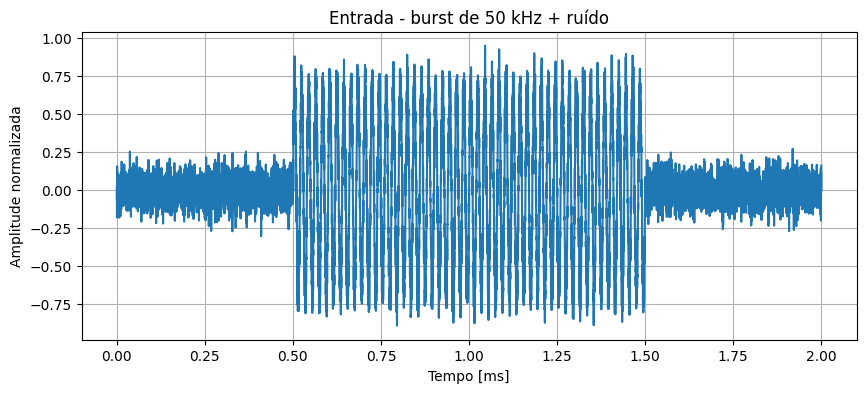

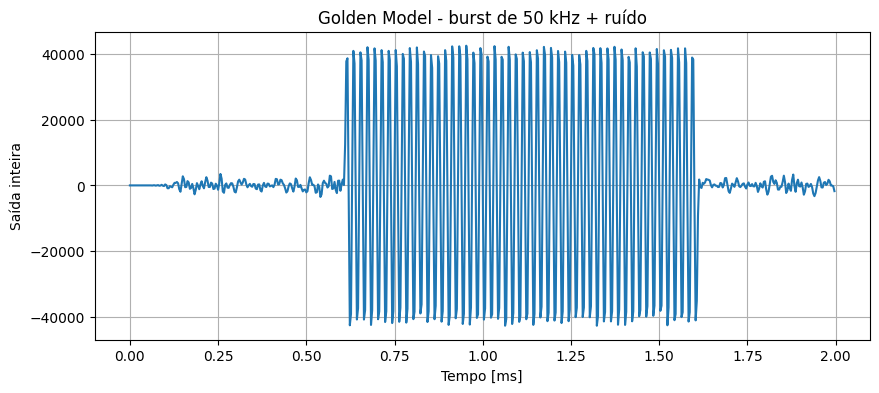

In [ ]:
# ============================================================
# CÉLULA 23 - VISUALIZAÇÃO DO BURST
# ============================================================

t_out_burst = (
    np.arange(
        len(y_burst)
    )
    /
    FS_OUT
)

plt.figure(figsize=(10, 4))

plt.plot(
    t_burst * 1e3,
    sinal_burst
)

plt.xlabel("Tempo [ms]")
plt.ylabel("Amplitude normalizada")

plt.title(
    "Entrada - burst de 50 kHz + ruído"
)

plt.grid()
plt.show()


plt.figure(figsize=(10, 4))

plt.plot(
    t_out_burst * 1e3,
    y_burst
)

plt.xlabel("Tempo [ms]")
plt.ylabel("Saída inteira")

plt.title(
    "Golden Model - burst de 50 kHz + ruído"
)

plt.grid()
plt.show()

In [ ]:
# ============================================================
# CÉLULA 24 - SUÍTE OFICIAL DE VETORES
# ============================================================

testes_oficiais = {
    "test_01_10k": {
        "pdm": resultados_seno[10e3]["pdm"],
        "y": resultados_seno[10e3]["y"]
    },

    "test_02_30k": {
        "pdm": resultados_seno[30e3]["pdm"],
        "y": resultados_seno[30e3]["y"]
    },

    "test_03_50k": {
        "pdm": resultados_seno[50e3]["pdm"],
        "y": resultados_seno[50e3]["y"]
    },

    "test_04_80k": {
        "pdm": resultados_seno[80e3]["pdm"],
        "y": resultados_seno[80e3]["y"]
    },

    "test_05_50k_ruido": {
        "pdm": pdm_50k_ruido,
        "y": y_50k_ruido
    },

    "test_06_burst_50k_ruido": {
        "pdm": pdm_burst,
        "y": y_burst
    }
}

print(
    "Teste | entrada PDM | saída Golden"
)

print("-" * 50)

for nome, dados in testes_oficiais.items():

    print(
        f"{nome:25s} | "
        f"{len(dados['pdm']):5d} | "
        f"{len(dados['y']):5d}"
    )

Teste | entrada PDM | saída Golden
--------------------------------------------------
test_01_10k               |  9600 |   600
test_02_30k               |  9600 |   600
test_03_50k               |  9600 |   600
test_04_80k               |  9600 |   600
test_05_50k_ruido         |  9600 |   600
test_06_burst_50k_ruido   |  9600 |   600


In [ ]:
# ============================================================
# CÉLULA 25 - GERAÇÃO DOS VETORES OFICIAIS
# ============================================================

import os

PASTA_VETORES = "vetores_golden"

os.makedirs(
    PASTA_VETORES,
    exist_ok=True
)

for nome, dados in testes_oficiais.items():

    arquivo_pdm = os.path.join(
        PASTA_VETORES,
        f"{nome}_input_pdm.txt"
    )

    arquivo_saida = os.path.join(
        PASTA_VETORES,
        f"{nome}_output_golden.txt"
    )

    np.savetxt(
        arquivo_pdm,
        dados["pdm"].astype(int),
        fmt="%d"
    )

    np.savetxt(
        arquivo_saida,
        dados["y"].astype(int),
        fmt="%d"
    )

    print(
        f"{nome}: arquivos gerados"
    )

print()
print("Vetores oficiais gerados com sucesso.")

test_01_10k: arquivos gerados
test_02_30k: arquivos gerados
test_03_50k: arquivos gerados
test_04_80k: arquivos gerados
test_05_50k_ruido: arquivos gerados
test_06_burst_50k_ruido: arquivos gerados

Vetores oficiais gerados com sucesso.


In [ ]:
# ============================================================
# CÉLULA 26 - VERIFICAÇÃO DOS ARQUIVOS GERADOS
# ============================================================

print(
    "Teste | PDM | Golden | conteúdo"
)

print("-" * 65)

for nome, dados in testes_oficiais.items():

    arquivo_pdm = os.path.join(
        PASTA_VETORES,
        f"{nome}_input_pdm.txt"
    )

    arquivo_saida = os.path.join(
        PASTA_VETORES,
        f"{nome}_output_golden.txt"
    )

    pdm_lido = np.loadtxt(
        arquivo_pdm,
        dtype=int
    )

    y_lido = np.loadtxt(
        arquivo_saida,
        dtype=int
    )

    pdm_ok = np.array_equal(
        pdm_lido,
        dados["pdm"].astype(int)
    )

    y_ok = np.array_equal(
        y_lido,
        dados["y"].astype(int)
    )

    tamanho_ok = (
        len(pdm_lido)
        ==
        CIC_R * len(y_lido)
    )

    tudo_ok = (
        pdm_ok
        and y_ok
        and tamanho_ok
    )

    print(
        f"{nome:25s} | "
        f"{len(pdm_lido):4d} | "
        f"{len(y_lido):3d} | "
        f"{'OK' if tudo_ok else 'ERRO'}"
    )

Teste | PDM | Golden | conteúdo
-----------------------------------------------------------------
test_01_10k               | 9600 | 600 | OK
test_02_30k               | 9600 | 600 | OK
test_03_50k               | 9600 | 600 | OK
test_04_80k               | 9600 | 600 | OK
test_05_50k_ruido         | 9600 | 600 | OK
test_06_burst_50k_ruido   | 9600 | 600 | OK


In [ ]:
# ============================================================
# CÉLULA 27 - SALVAR COEFICIENTES FIR
# ============================================================

arquivo_coef = os.path.join(
    PASTA_VETORES,
    "fir_coef_q15.txt"
)

np.savetxt(
    arquivo_coef,
    FIR_COEF_Q15.astype(int),
    fmt="%d"
)

print(
    f"Coeficientes salvos em: "
    f"{arquivo_coef}"
)

print(
    f"Número de coeficientes = "
    f"{len(FIR_COEF_Q15)}"
)

Coeficientes salvos em: vetores_golden/fir_coef_q15.txt
Número de coeficientes = 65


In [ ]:
# ============================================================
# CÉLULA 28 - VERIFICAR COEFICIENTES SALVOS
# ============================================================

coef_lidos = np.loadtxt(
    arquivo_coef,
    dtype=int
)

coef_ok = np.array_equal(
    coef_lidos,
    FIR_COEF_Q15
)

print(
    f"Coeficientes recuperados = "
    f"{len(coef_lidos)}"
)

print(
    f"Conteúdo = "
    f"{'OK' if coef_ok else 'ERRO'}"
)

assert coef_ok

Coeficientes recuperados = 65
Conteúdo = OK


In [ ]:
# ============================================================
# CÉLULA 29 - METADADOS DA ARQUITETURA
# ============================================================

arquivo_config = os.path.join(
    PASTA_VETORES,
    "golden_model_config.txt"
)

with open(
    arquivo_config,
    "w"
) as f:

    f.write("GOLDEN MODEL - CIC + FIR\n")
    f.write("========================\n")

    f.write(
        f"FS_PDM_HZ={int(FS_PDM)}\n"
    )

    f.write(
        f"FS_OUT_HZ={int(FS_OUT)}\n"
    )

    f.write(
        f"CIC_N={CIC_N}\n"
    )

    f.write(
        f"CIC_R={CIC_R}\n"
    )

    f.write(
        f"CIC_M={CIC_M}\n"
    )

    f.write(
        f"BITS_CIC={BITS_CIC}\n"
    )

    f.write(
        f"FIR_TAPS={FIR_TAPS}\n"
    )

    f.write(
        f"BITS_COEF={BITS_COEF}\n"
    )

    f.write(
        f"FRAC_COEF={FRAC_COEF}\n"
    )

    f.write(
        f"BITS_ACC_FIR={BITS_ACC_FIR}\n"
    )

    f.write(
        f"BITS_SAIDA={BITS_SAIDA}\n"
    )

print(
    f"Configuração salva em: "
    f"{arquivo_config}"
)

Configuração salva em: vetores_golden/golden_model_config.txt


In [ ]:
# ============================================================
# CÉLULA 30 - INVENTÁRIO FINAL
# ============================================================

print("=== ARQUIVOS DO GOLDEN MODEL ===")

for nome in sorted(
    os.listdir(PASTA_VETORES)
):
    print(nome)

=== ARQUIVOS DO GOLDEN MODEL ===
fir_coef_q15.txt
golden_model_config.txt
test_01_10k_input_pdm.txt
test_01_10k_output_golden.txt
test_02_30k_input_pdm.txt
test_02_30k_output_golden.txt
test_03_50k_input_pdm.txt
test_03_50k_output_golden.txt
test_04_80k_input_pdm.txt
test_04_80k_output_golden.txt
test_05_50k_ruido_input_pdm.txt
test_05_50k_ruido_output_golden.txt
test_06_burst_50k_ruido_input_pdm.txt
test_06_burst_50k_ruido_output_golden.txt


In [ ]:
!ls -lh vetores_golden

total 152K
-rw-r--r-- 1 root root  288 Oct  3 19:02 fir_coef_q15.txt
-rw-r--r-- 1 root root  190 Oct  3 19:02 golden_model_config.txt
-rw-r--r-- 1 root root  19K Oct  3 19:02 test_01_10k_input_pdm.txt
-rw-r--r-- 1 root root 3.7K Oct  3 19:02 test_01_10k_output_golden.txt
-rw-r--r-- 1 root root  19K Oct  3 19:02 test_02_30k_input_pdm.txt
-rw-r--r-- 1 root root 3.7K Oct  3 19:02 test_02_30k_output_golden.txt
-rw-r--r-- 1 root root  19K Oct  3 19:02 test_03_50k_input_pdm.txt
-rw-r--r-- 1 root root 3.6K Oct  3 19:02 test_03_50k_output_golden.txt
-rw-r--r-- 1 root root  19K Oct  3 19:02 test_04_80k_input_pdm.txt
-rw-r--r-- 1 root root 3.7K Oct  3 19:02 test_04_80k_output_golden.txt
-rw-r--r-- 1 root root  19K Oct  3 19:02 test_05_50k_ruido_input_pdm.txt
-rw-r--r-- 1 root root 3.6K Oct  3 19:02 test_05_50k_ruido_output_golden.txt
-rw-r--r-- 1 root root  19K Oct  3 19:02 test_06_burst_50k_ruido_input_pdm.txt
-rw-r--r-- 1 root root 3.2K Oct  3 19:02 test_06_burst_50k_ruido_output_golden.txt


In [ ]:
!zip -r /content/vetores_golden.zip /content/vetores_golden

  adding: content/vetores_golden/ (stored 0%)
  adding: content/vetores_golden/test_05_50k_ruido_output_golden.txt (deflated 55%)
  adding: content/vetores_golden/test_04_80k_input_pdm.txt (deflated 99%)
  adding: content/vetores_golden/test_02_30k_input_pdm.txt (deflated 99%)
  adding: content/vetores_golden/golden_model_config.txt (deflated 35%)
  adding: content/vetores_golden/test_03_50k_output_golden.txt (deflated 82%)
  adding: content/vetores_golden/test_06_burst_50k_ruido_output_golden.txt (deflated 53%)
  adding: content/vetores_golden/test_05_50k_ruido_input_pdm.txt (deflated 94%)
  adding: content/vetores_golden/test_03_50k_input_pdm.txt (deflated 99%)
  adding: content/vetores_golden/test_04_80k_output_golden.txt (deflated 76%)
  adding: content/vetores_golden/test_02_30k_output_golden.txt (deflated 94%)
  adding: content/vetores_golden/test_06_burst_50k_ruido_input_pdm.txt (deflated 95%)
  adding: content/vetores_golden/test_01_10k_output_golden.txt (deflated 89%)
  adding

In [ ]:
from google.colab import files
files.download('/content/vetores_golden.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# EXPORTAÇÃO DA SAÍDA INTERMEDIÁRIA DO CIC
# Teste oficial: senoide de 50 kHz
# ============================================================

import numpy as np

# Lê o vetor PDM oficial de 50 kHz
pdm_50k = np.loadtxt(
    "vetores_golden/test_03_50k_input_pdm.txt",
    dtype=np.int64
)

# Executa SOMENTE o CIC definitivo
# A própria função converte:
# 0 -> -1
# 1 -> +1
saida_cic = cic_fixed_point(pdm_50k)

# Salva a referência intermediária do CIC
np.savetxt(
    "test_03_50k_output_cic_golden.txt",
    saida_cic,
    fmt="%d"
)

print("Entrada PDM:", len(pdm_50k))
print("Saída CIC:", len(saida_cic))
print("Mínimo:", np.min(saida_cic))
print("Máximo:", np.max(saida_cic))

print("\nPrimeiras 20 amostras:")
print(saida_cic[:20])

Entrada PDM: 9600
Saída CIC: 600
Mínimo: -39148
Máximo: 39168

Primeiras 20 amostras:
[   754  12664  39168  36692  -2790 -39148 -36110   2392  38964  36692
  -2790 -39148 -36110   2392  38964  36692  -2790 -39148 -36110   2392]


In [ ]:
from google.colab import files

files.download("test_03_50k_output_cic_golden.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# REFERÊNCIA INTERMEDIÁRIA DO CIC - TESTE 10 kHz
# ============================================================

# Usa EXATAMENTE o mesmo PDM da suíte oficial
pdm_10k = resultados_seno[10e3]["pdm"]

# Executa somente o CIC
saida_cic_10k = cic_fixed_point(pdm_10k)

# Salva a referência intermediária
np.savetxt(
    "test_01_10k_output_cic_golden.txt",
    saida_cic_10k,
    fmt="%d"
)

print("Entrada PDM:", len(pdm_10k))
print("Saída CIC:", len(saida_cic_10k))
print("Mínimo:", np.min(saida_cic_10k))
print("Máximo:", np.max(saida_cic_10k))

print("\nPrimeiras 20 amostras:")
print(saida_cic_10k[:20])

Entrada PDM: 9600
Saída CIC: 600
Mínimo: -51942
Máximo: 51884

Primeiras 20 amostras:
[   446   2928  11326  21810  30778  39418  45510  49406  51884  51574
  49678  44654  38000  30222  20476  10530   -716 -11502 -21826 -31288]


In [ ]:
import shutil

shutil.copy(
    "test_01_10k_output_cic_golden.txt",
    "vetores_golden/test_01_10k_output_cic_golden.txt"
)

print("Arquivo CIC copiado para vetores_golden.")

Arquivo CIC copiado para vetores_golden.


In [ ]:
# ============================================================
# VETOR GOLDEN SOMENTE DO CIC - 30 kHz
# ============================================================

pdm_30k = resultados_seno[30e3]["pdm"]

saida_cic_30k = cic_fixed_point(pdm_30k)

np.savetxt(
    "test_02_30k_output_cic_golden.txt",
    saida_cic_30k,
    fmt="%d"
)

print("Entrada PDM:", len(pdm_30k))
print("Saída CIC:", len(saida_cic_30k))
print("Mínimo:", np.min(saida_cic_30k))
print("Máximo:", np.max(saida_cic_30k))

print("\nPrimeiras 20 amostras:")
print(saida_cic_30k[:20])

Entrada PDM: 9600
Saída CIC: 600
Mínimo: -47782
Máximo: 47050

Primeiras 20 amostras:
[   572   8302  30620  47050  45834  27390  -1576 -30182 -47782 -45746
 -26690   1416  30286  47050  45834  27390  -1576 -30182 -47782 -45746]


In [ ]:
# ============================================================
# VETOR GOLDEN SOMENTE DO CIC - 50 kHz
# ============================================================

pdm_50k = resultados_seno[50e3]["pdm"]

saida_cic_50k = cic_fixed_point(pdm_50k)

np.savetxt(
    "test_03_50k_output_cic_golden.txt",
    saida_cic_50k,
    fmt="%d"
)

print("Entrada PDM:", len(pdm_50k))
print("Saída CIC:", len(saida_cic_50k))
print("Mínimo:", np.min(saida_cic_50k))
print("Máximo:", np.max(saida_cic_50k))

print("\nPrimeiras 20 amostras:")
print(saida_cic_50k[:20])

Entrada PDM: 9600
Saída CIC: 600
Mínimo: -39148
Máximo: 39168

Primeiras 20 amostras:
[   754  12664  39168  36692  -2790 -39148 -36110   2392  38964  36692
  -2790 -39148 -36110   2392  38964  36692  -2790 -39148 -36110   2392]


In [ ]:
# ============================================================
# VETOR GOLDEN SOMENTE DO CIC - 80 kHz
# ============================================================

pdm_80k = resultados_seno[80e3]["pdm"]

saida_cic_80k = cic_fixed_point(pdm_80k)

np.savetxt(
    "test_04_80k_output_cic_golden.txt",
    saida_cic_80k,
    fmt="%d"
)

print("Entrada PDM:", len(pdm_80k))
print("Saída CIC:", len(saida_cic_80k))
print("Mínimo:", np.min(saida_cic_80k))
print("Máximo:", np.max(saida_cic_80k))

print("\nPrimeiras 20 amostras:")
print(saida_cic_80k[:20])

Entrada PDM: 9600
Saída CIC: 600
Mínimo: -32894
Máximo: 32652

Primeiras 20 amostras:
[  1096  17036  32652 -10216 -29718  16136  26648 -22022 -21718  26252
  16512 -29960 -10042  31928   3424 -32622   3286  32112 -10216 -29718]


In [ ]:
# ============================================================
# GOLDEN SOMENTE DO CIC - TESTES COM RUÍDO E BURST
# ============================================================

# Teste 05 - 50 kHz + ruído
saida_cic_50k_ruido = cic_fixed_point(pdm_50k_ruido)

np.savetxt(
    "test_05_50k_ruido_output_cic_golden.txt",
    saida_cic_50k_ruido,
    fmt="%d"
)


# Teste 06 - burst de 50 kHz + ruído
saida_cic_burst = cic_fixed_point(pdm_burst)

np.savetxt(
    "test_06_burst_50k_ruido_output_cic_golden.txt",
    saida_cic_burst,
    fmt="%d"
)


print("TESTE 05")
print("Entrada:", len(pdm_50k_ruido))
print("Saída CIC:", len(saida_cic_50k_ruido))
print("Min/Max:", np.min(saida_cic_50k_ruido),
                  np.max(saida_cic_50k_ruido))

print()

print("TESTE 06")
print("Entrada:", len(pdm_burst))
print("Saída CIC:", len(saida_cic_burst))
print("Min/Max:", np.min(saida_cic_burst),
                  np.max(saida_cic_burst))

TESTE 05
Entrada: 9600
Saída CIC: 600
Min/Max: -36850 36970

TESTE 06
Entrada: 9600
Saída CIC: 600
Min/Max: -35816 35878


Vamos. Como o **CIC RTL já passou nos seis vetores com erro zero**, eu faria agora a consolidação do que implementamos antes de partir para o FIR. Isso vai ser importante tanto para você dominar o SystemVerilog quanto para depois explicar a implementação no TCC.

### 1. O que o CIC RTL que construímos faz

Nosso CIC implementa, em hardware, esta cadeia:

```text
x[n] @ 4,8 MHz
     │
     ▼
Integrador 1
     │
Integrador 2
     │
Integrador 3
     │
Integrador 4
     │
     ▼
 Decimação R=16
     │
     ▼
Comb 1
     │
Comb 2
     │
Comb 3
     │
Comb 4
     │
     ▼
y[n] @ 300 kHz
```

Isso corresponde aos parâmetros que congelamos no Golden Model:

$$
N=4,\qquad R=16,\qquad M=1
$$

e

$$
f_{out}=\frac{4{,}8\text{ MHz}}{16}=300\text{ kHz}.
$$

### 2. Começando pelo `integrador.sv`

Um único integrador CIC implementa essencialmente:

$$
y[n]=y[n-1]+x[n].
$$

Em hardware, portanto, precisamos de **um somador e um registrador**.

Imagine que a entrada seja:

```text
x[n]:       1    1   -1    1   -1
```

Começando o registrador em zero:

```text
Anterior    0    1    2    1    2
Entrada     1    1   -1    1   -1
            ↓    ↓    ↓    ↓    ↓
Saída       1    2    1    2    1
```

O integrador está acumulando as entradas.

Quando colocamos **quatro integradores em cascata**, fazemos:

$$
I_1[n]=I_1[n-1]+x[n]
$$

$$
I_2[n]=I_2[n-1]+I_1[n]
$$

$$
I_3[n]=I_3[n-1]+I_2[n]
$$

$$
I_4[n]=I_4[n-1]+I_3[n].
$$

E aqui apareceu aquele detalhe muito importante que corrigimos no RTL.

No SystemVerilog, se escrevêssemos simplesmente dentro de um `always_ff`:

```systemverilog
int1 <= int1 + x_in;
int2 <= int2 + int1;
int3 <= int3 + int2;
int4 <= int4 + int3;
```

o operador `<=` é uma **atribuição não bloqueante**. Isso significa que `int2` utiliza o valor **anterior** de `int1`, `int3` utiliza o anterior de `int2`, etc.

Mas nosso Golden Model Python atualizava os estágios sequencialmente dentro da mesma amostra.

Foi por isso que fizemos:

```systemverilog
next_int1 = int1 + x_in;
next_int2 = int2 + next_int1;
next_int3 = int3 + next_int2;
next_int4 = int4 + next_int3;
```

e depois:

```systemverilog
int1 <= next_int1;
int2 <= next_int2;
int3 <= next_int3;
int4 <= next_int4;
```

Essa mudança foi crucial para obtermos a equivalência **bit a bit** com o Golden Model.

### 3. E por que não colocamos manualmente `wrap_signed()` no RTL?

No Python precisávamos fazer explicitamente algo como:

```python
wrap_signed(valor, 17)
```

porque os inteiros do Python não têm naturalmente uma largura fixa de 17 bits.

No RTL, entretanto, declaramos:

```systemverilog
logic signed [BITS-1:0]
```

com:

```systemverilog
BITS = 17;
```

Então o próprio sinal possui largura fixa.

Se uma operação ultrapassar:

$$
+65535
$$

o resultado armazenado nos 17 bits sofre naturalmente o comportamento modular de complemento de dois que estamos modelando.

Por isso nosso RTL consegue reproduzir o `wrap_signed(..., 17)` do Python sem precisar criar uma função chamada `wrap_signed`.

Isso é uma conexão muito importante entre **modelo numérico** e **hardware real**.

---

### 4. Depois vem o `decimador.sv`

Depois dos quatro integradores ainda estamos processando na frequência:

$$
4{,}8\text{ MHz}.
$$

O decimador possui um contador:

```text
0 1 2 3 ... 14 15
                ↑
              valid
```

A cada 16 ciclos ele sinaliza que uma amostra deve seguir adiante.

Portanto:

```text
4.800.000 amostras/s
          │
          │ R = 16
          ▼
  300.000 amostras/s
```

Isso explica exatamente o resultado que acabamos de observar:

$$
\frac{9600}{16}=600.
$$

Por isso o terminal mostrar

```text
Entradas aplicadas : 9600
Saidas RTL         : 600
```

é uma validação estrutural muito importante.

---

### 5. Depois entram os `comb`

Um comb com \(M=1\) implementa:

$$
y[n]=x[n]-x[n-1].
$$

Ou seja, enquanto o integrador **soma ao longo do tempo**, o comb calcula uma **diferença entre amostras**.

Exemplo:

```text
x[n]       10    15    18    17
x[n-1]      0    10    15    18
           ─────────────────────
y[n]       10     5     3    -1
```

Como nosso CIC possui ordem \(N=4\), utilizamos quatro:

```text
decimador
    │
    ▼
 comb1 → comb2 → comb3 → comb4
```

E os sinais `valid1`, `valid2`, `valid3` vão acompanhando as amostras à medida que elas atravessam esses estágios.

---

### 6. O `cic.sv` é quem monta tudo

O `cic.sv` não precisa implementar novamente as equações matemáticas. Ele funciona como o **módulo estrutural superior**:

```text
                cic.sv
┌─────────────────────────────────┐
│                                 │
│ cic_integradores                │
│        │                        │
│        ▼                        │
│    decimador                    │
│        │                        │
│        ▼                        │
│    cic_combs                    │
│        │                        │
└────────┼────────────────────────┘
         ▼
       y_out
```

Isso é uma prática importante de projeto digital: dividir uma arquitetura maior em **módulos menores, verificáveis e reutilizáveis**.

### 7. E finalmente o `tb_cic_golden.sv`

O testbench não fará parte do ASIC. Ele existe para **verificar o circuito**.

O fluxo que construímos é:

```text
Golden Model Python
       │
       ├── PDM de entrada ─────────────┐
       │                               │
       └── saída CIC esperada ───┐     │
                                 │     ▼
                                 │   CIC RTL
                                 │     │
                                 │     ▼
                                 └── comparação
                                        │
                                   RTL == Golden?
```

E não estamos perguntando apenas se as curvas "parecem iguais".

Estamos fazendo:

$$
y_{\text{RTL}}[n] \stackrel{?}{=} y_{\text{Golden}}[n]
$$

para **cada amostra**.

Nos seis testes obtivemos:

$$
N_{\text{erros}}=0.
$$

Esse é um resultado muito forte para documentarmos: **a implementação RTL do estágio CIC apresentou equivalência bit a bit com o modelo de referência em todos os vetores de validação utilizados.**

---

## Agora entramos no FIR

A próxima etapa fica:

```text
PDM
 │
 ▼
CIC RTL                 ✅ VALIDADO
 │
 │ 17 bits
 │ 300 kHz
 ▼
FIR compensador         ← AGORA
 │
 │ 19 bits
 ▼
saída
```

Aqui aparece uma diferença grande em relação ao CIC: **multiplicações**.

Nosso FIR possui 65 coeficientes:

$$
y[n]=\sum_{k=0}^{64}h[k]x[n-k].
$$

Mas os coeficientes são simétricos:

$$
h[k]=h[64-k].
$$

Então podemos reorganizar:

$$
y[n]
=
h[0](x[n]+x[n-64])
+h[1](x[n-1]+x[n-63])
+\cdots
+h[31](x[n-31]+x[n-33])
+h[32]x[n-32].
$$

Isso transforma conceitualmente **65 multiplicações em 33 caminhos de multiplicação**, usando a simetria do FIR.

E nosso objetivo continua exatamente o mesmo: implementar o FIR de maneira que reproduza **exatamente** o Golden Model com coeficientes **Q1.15 de 16 bits**, acumulador **34 bits** e saída **19 bits**.

**Próximo passo prático:** antes de escrever `fir.sv`, vamos abrir no Colab os **65 coeficientes inteiros definitivos do Golden Model** e entender exatamente o que o hardware terá de calcular. Isso evita escrevermos o RTL do FIR sem saber de onde cada número vem.


In [ ]:
# ============================================================
# INSPEÇÃO DOS COEFICIENTES DO FIR PARA IMPLEMENTAÇÃO RTL
# ============================================================

print("Quantidade de coeficientes:", len(FIR_COEF_Q15))
print("Tipo:", FIR_COEF_Q15.dtype)

print("\nCoeficientes Q1.15:")
for i, coef in enumerate(FIR_COEF_Q15):
    print(f"h[{i:2d}] = {int(coef):6d}")

print("\nSimetria:")
print("FIR_COEF_Q15 == reverso:",
      np.array_equal(FIR_COEF_Q15, FIR_COEF_Q15[::-1]))

print("\nMínimo:", np.min(FIR_COEF_Q15))
print("Máximo:", np.max(FIR_COEF_Q15))

Quantidade de coeficientes: 65
Tipo: int64

Coeficientes Q1.15:
h[ 0] =     -6
h[ 1] =     -2
h[ 2] =     14
h[ 3] =    -11
h[ 4] =    -22
h[ 5] =     43
h[ 6] =     -4
h[ 7] =    -80
h[ 8] =     82
h[ 9] =     56
h[10] =   -196
h[11] =     81
h[12] =    218
h[13] =   -330
h[14] =    -28
h[15] =    515
h[16] =   -404
h[17] =   -389
h[18] =    869
h[19] =   -207
h[20] =  -1010
h[21] =   1065
h[22] =    394
h[23] =  -1849
h[24] =    920
h[25] =   1915
h[26] =  -2661
h[27] =   -709
h[28] =   4553
h[29] =  -2307
h[30] =  -6823
h[31] =  10412
h[32] =  24614
h[33] =  10412
h[34] =  -6823
h[35] =  -2307
h[36] =   4553
h[37] =   -709
h[38] =  -2661
h[39] =   1915
h[40] =    920
h[41] =  -1849
h[42] =    394
h[43] =   1065
h[44] =  -1010
h[45] =   -207
h[46] =    869
h[47] =   -389
h[48] =   -404
h[49] =    515
h[50] =    -28
h[51] =   -330
h[52] =    218
h[53] =     81
h[54] =   -196
h[55] =     56
h[56] =     82
h[57] =    -80
h[58] =     -4
h[59] =     43
h[60] =    -22
h[61] =    -11
h[62] 

In [ ]:
# ============================================================
# VETORES PARA VALIDAÇÃO DO FIR RTL - TESTE 10 kHz
# ============================================================

pdm_10k = resultados_seno[10e3]["pdm"]

# Entrada do FIR = saída do CIC
entrada_fir_10k = cic_fixed_point(pdm_10k)

# Golden esperado do FIR
saida_fir_10k = fir_fixed_point(entrada_fir_10k)

np.savetxt(
    "test_01_10k_input_fir.txt",
    entrada_fir_10k,
    fmt="%d"
)

np.savetxt(
    "test_01_10k_output_fir_golden.txt",
    saida_fir_10k,
    fmt="%d"
)

print("Entrada FIR :", len(entrada_fir_10k))
print("Saída FIR   :", len(saida_fir_10k))

print("Entrada min/max:",
      np.min(entrada_fir_10k),
      np.max(entrada_fir_10k))

print("Saída min/max:",
      np.min(saida_fir_10k),
      np.max(saida_fir_10k))

print("\nPrimeiras 20 entradas FIR:")
print(entrada_fir_10k[:20])

print("\nPrimeiras 20 saídas FIR:")
print(saida_fir_10k[:20])

Entrada FIR : 600
Saída FIR   : 600
Entrada min/max: -51942 51884
Saída min/max: -52505 52589

Primeiras 20 entradas FIR:
[   446   2928  11326  21810  30778  39418  45510  49406  51884  51574
  49678  44654  38000  30222  20476  10530   -716 -11502 -21826 -31288]

Primeiras 20 saídas FIR:
[  0  -1  -2  -4  -3  -5  -9  -7  -6 -15 -12  -2 -21 -25   0 -24 -45   8
  -3 -66]


In [ ]:
# ============================================================
# VETORES PARA VALIDAÇÃO DO FIR RTL
# TODOS OS TESTES
# ============================================================

vetores_fir = {}

# ------------------------------------------------------------
# 1) SENO 10 kHz
# ------------------------------------------------------------

pdm = resultados_seno[10e3]["pdm"]
entrada = cic_fixed_point(pdm)
saida = fir_fixed_point(entrada)

vetores_fir["test_01_10k"] = (entrada, saida)


# ------------------------------------------------------------
# 2) SENO 30 kHz
# ------------------------------------------------------------

pdm = resultados_seno[30e3]["pdm"]
entrada = cic_fixed_point(pdm)
saida = fir_fixed_point(entrada)

vetores_fir["test_02_30k"] = (entrada, saida)


# ------------------------------------------------------------
# 3) SENO 50 kHz
# ------------------------------------------------------------

pdm = resultados_seno[50e3]["pdm"]
entrada = cic_fixed_point(pdm)
saida = fir_fixed_point(entrada)

vetores_fir["test_03_50k"] = (entrada, saida)


# ------------------------------------------------------------
# 4) SENO 80 kHz
# ------------------------------------------------------------

pdm = resultados_seno[80e3]["pdm"]
entrada = cic_fixed_point(pdm)
saida = fir_fixed_point(entrada)

vetores_fir["test_04_80k"] = (entrada, saida)


# ------------------------------------------------------------
# Os testes 5 e 6 já possuem seus sinais PDM no notebook.
#
# NÃO vamos adivinhar os nomes dessas variáveis aqui.
# Primeiro vamos confirmar como elas foram chamadas.
# ------------------------------------------------------------


# ------------------------------------------------------------
# Exporta por enquanto os quatro testes senoidais
# ------------------------------------------------------------

for nome, (entrada, saida) in vetores_fir.items():

    np.savetxt(
        f"{nome}_input_fir.txt",
        entrada,
        fmt="%d"
    )

    np.savetxt(
        f"{nome}_output_fir_golden.txt",
        saida,
        fmt="%d"
    )

    print(
        nome,
        "| entrada:", len(entrada),
        "| saída:", len(saida),
        "| min/max entrada:",
        np.min(entrada),
        np.max(entrada),
        "| min/max saída:",
        np.min(saida),
        np.max(saida)
    )

test_01_10k | entrada: 600 | saída: 600 | min/max entrada: -51942 51884 | min/max saída: -52505 52589
test_02_30k | entrada: 600 | saída: 600 | min/max entrada: -47782 47050 | min/max saída: -51179 50699
test_03_50k | entrada: 600 | saída: 600 | min/max entrada: -39148 39168 | min/max saída: -48389 47021
test_04_80k | entrada: 600 | saída: 600 | min/max entrada: -32894 32652 | min/max saída: -53745 52370


In [ ]:
# Procura variáveis relacionadas aos testes com ruído e burst

for nome in sorted(globals()):
    nome_lower = nome.lower()

    if (
        "ruido" in nome_lower
        or "noise" in nome_lower
        or "burst" in nome_lower
    ):
        obj = globals()[nome]

        if isinstance(obj, np.ndarray):
            print(
                f"{nome:30s}",
                "shape =", obj.shape,
                "dtype =", obj.dtype,
                "min/max =", np.min(obj), np.max(obj)
            )
        else:
            print(
                f"{nome:30s}",
                "tipo =", type(obj).__name__
            )

burst_limpo                    shape = (9600,) dtype = float64 min/max = -0.7 0.7
duracao_burst                  tipo = float
duracao_ruido                  tipo = float
fim_burst                      tipo = float
inicio_burst                   tipo = float
janela_burst                   shape = (9600,) dtype = float64 min/max = 0.0 1.0
pdm_50k_ruido                  shape = (9600,) dtype = int8 min/max = 0 1
pdm_burst                      shape = (9600,) dtype = int8 min/max = 0 1
portadora_burst                shape = (9600,) dtype = float64 min/max = -1.0 1.0
ruido                          shape = (9600,) dtype = float64 min/max = -0.3104718729069286 0.2630230317737614
ruido_burst                    shape = (9600,) dtype = float64 min/max = -0.30447526276360676 0.3164864103266146
saida_cic_50k_ruido            shape = (600,) dtype = int64 min/max = -36850 36970
saida_cic_burst                shape = (600,) dtype = int64 min/max = -35816 35878
sinal_50k_ruido                shape = (

In [ ]:
# ============================================================
# VETORES FIR - TESTES 05 E 06
# ============================================================


# ------------------------------------------------------------
# TESTE 05 - 50 kHz + RUÍDO
# ------------------------------------------------------------

entrada_fir_05 = cic_fixed_point(
    pdm_50k_ruido
)

saida_fir_05 = fir_fixed_point(
    entrada_fir_05
)

np.savetxt(
    "test_05_50k_ruido_input_fir.txt",
    entrada_fir_05,
    fmt="%d"
)

np.savetxt(
    "test_05_50k_ruido_output_fir_golden.txt",
    saida_fir_05,
    fmt="%d"
)


# ------------------------------------------------------------
# TESTE 06 - BURST 50 kHz + RUÍDO
# ------------------------------------------------------------

entrada_fir_06 = cic_fixed_point(
    pdm_burst
)

saida_fir_06 = fir_fixed_point(
    entrada_fir_06
)

np.savetxt(
    "test_06_burst_50k_ruido_input_fir.txt",
    entrada_fir_06,
    fmt="%d"
)

np.savetxt(
    "test_06_burst_50k_ruido_output_fir_golden.txt",
    saida_fir_06,
    fmt="%d"
)


# ------------------------------------------------------------
# VERIFICAÇÕES
# ------------------------------------------------------------

print("TESTE 05")
print("Entrada FIR:", len(entrada_fir_05))
print("Saída FIR  :", len(saida_fir_05))
print(
    "Entrada min/max:",
    np.min(entrada_fir_05),
    np.max(entrada_fir_05)
)
print(
    "Saída min/max:",
    np.min(saida_fir_05),
    np.max(saida_fir_05)
)


print("\nTESTE 06")
print("Entrada FIR:", len(entrada_fir_06))
print("Saída FIR  :", len(saida_fir_06))
print(
    "Entrada min/max:",
    np.min(entrada_fir_06),
    np.max(entrada_fir_06)
)
print(
    "Saída min/max:",
    np.min(saida_fir_06),
    np.max(saida_fir_06)
)


# ------------------------------------------------------------
# CONFERE CONTRA AS VARIÁVEIS JÁ EXISTENTES NO NOTEBOOK
# ------------------------------------------------------------

print("\nConferência com resultados já existentes:")

print(
    "Teste 05 igual a y_50k_ruido:",
    np.array_equal(saida_fir_05, y_50k_ruido)
)

print(
    "Teste 06 igual a y_burst:",
    np.array_equal(saida_fir_06, y_burst)
)

TESTE 05
Entrada FIR: 600
Saída FIR  : 600
Entrada min/max: -36850 36970
Saída min/max: -44353 44383

TESTE 06
Entrada FIR: 600
Saída FIR  : 600
Entrada min/max: -35816 35878
Saída min/max: -42717 42520

Conferência com resultados já existentes:
Teste 05 igual a y_50k_ruido: True
Teste 06 igual a y_burst: True


In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

FS_OUT = 300_000

rtl = np.loadtxt(
    "test_03_50k_output_rtl.txt",
    dtype=np.int64
)

print("Número de amostras:", len(rtl))
print("Mínimo:", rtl.min())
print("Máximo:", rtl.max())
print("Primeiras 20 amostras:")
print(rtl[:20])

FileNotFoundError: test_03_50k_output_rtl.txt not found.

In [ ]:
# ============================================================
# SAÍDA RTL NO DOMÍNIO DO TEMPO
# ============================================================

# Eixo de tempo da saída
t = np.arange(len(rtl)) / FS_OUT

plt.figure(figsize=(12, 4))

plt.plot(
    t * 1e3,
    rtl,
    linewidth=1.2
)

plt.xlabel("Tempo (ms)")
plt.ylabel("Amplitude digital")
plt.title("Saída RTL do filtro completo - sinal de 50 kHz")

plt.grid(True)
plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# ZOOM DA SAÍDA RTL EM REGIME PERMANENTE
# ============================================================

# Região entre 0,5 ms e 0,7 ms
mascara = (t >= 0.5e-3) & (t <= 0.7e-3)

plt.figure(figsize=(12, 4))

plt.plot(
    t[mascara] * 1e3,
    rtl[mascara],
    marker="o",
    linewidth=1.2
)

plt.xlabel("Tempo (ms)")
plt.ylabel("Amplitude digital")
plt.title("Saída RTL em regime permanente - 50 kHz")

plt.grid(True)
plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# COMPARAÇÃO BIT A BIT: RTL x GOLDEN MODEL
# ============================================================

golden = y_50k.astype(np.int64)

erro = rtl - golden

print("Número de amostras RTL   :", len(rtl))
print("Número de amostras Golden:", len(golden))

print()
print("RTL idêntico ao Golden?  :", np.array_equal(rtl, golden))
print("Número de diferenças     :", np.count_nonzero(erro))
print("Erro máximo absoluto     :", np.max(np.abs(erro)))

In [ ]:
# ============================================================
# COMPARAÇÃO VISUAL: RTL x GOLDEN MODEL
# ============================================================

# Vamos observar apenas uma região em regime permanente
mascara = (t >= 0.5e-3) & (t <= 0.7e-3)

plt.figure(figsize=(12, 4))

plt.plot(
    t[mascara] * 1e3,
    golden[mascara],
    linewidth=2.5,
    label="Golden Model"
)

plt.plot(
    t[mascara] * 1e3,
    rtl[mascara],
    "o",
    markersize=4,
    label="RTL - Synopsys VCS"
)

plt.xlabel("Tempo (ms)")
plt.ylabel("Amplitude digital")
plt.title("Comparação RTL x Golden Model - 50 kHz")

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# ERRO AMOSTRA A AMOSTRA: RTL - GOLDEN
# ============================================================

erro = rtl - golden

plt.figure(figsize=(12, 4))

plt.plot(
    np.arange(len(erro)),
    erro,
    marker=".",
    linewidth=1
)

plt.xlabel("Índice da amostra")
plt.ylabel("Erro (RTL - Golden)")
plt.title("Erro amostra a amostra - RTL x Golden Model")

plt.grid(True)
plt.tight_layout()

plt.show()

print("Erro mínimo:", erro.min())
print("Erro máximo:", erro.max())
print("Erro máximo absoluto:", np.max(np.abs(erro)))
print("Número de amostras diferentes:", np.count_nonzero(erro))

In [ ]:
# ============================================================
# FFT DA SAÍDA RTL - TESTE DE 50 kHz
# ============================================================

# Remove o transitório inicial
rtl_fft = rtl[120:600].astype(float)

N = len(rtl_fft)

# Remove eventual componente DC
rtl_fft = rtl_fft - np.mean(rtl_fft)

# FFT para sinal real
X = np.fft.rfft(rtl_fft)

# Eixo de frequências
freq = np.fft.rfftfreq(
    N,
    d=1 / FS_OUT
)

# Magnitude
magnitude = np.abs(X)

# Normalização pelo maior valor
magnitude_db = 20 * np.log10(
    np.maximum(
        magnitude / np.max(magnitude),
        1e-12
    )
)

# Frequência correspondente ao maior pico
indice_pico = np.argmax(magnitude[1:]) + 1
frequencia_pico = freq[indice_pico]

print("Número de amostras analisadas:", N)
print("Resolução em frequência:", FS_OUT / N, "Hz")
print("Maior pico espectral:", frequencia_pico, "Hz")

plt.figure(figsize=(12, 4))

plt.plot(
    freq / 1000,
    magnitude_db,
    linewidth=1.2
)

plt.xlabel("Frequência (kHz)")
plt.ylabel("Magnitude normalizada (dB)")
plt.title("Espectro da saída RTL - sinal de 50 kHz")

plt.xlim(0, FS_OUT / 2 / 1000)
plt.ylim(-100, 5)

plt.grid(True)
plt.tight_layout()

plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test_03_50k_output_rtl.txt to test_03_50k_output_rtl.txt


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test_03_50k_output_golden.txt to test_03_50k_output_golden.txt


In [ ]:
import numpy as np

rtl = np.loadtxt(
    "test_03_50k_output_rtl.txt",
    dtype=np.int64
)

golden = np.loadtxt(
    "test_03_50k_output_golden.txt",
    dtype=np.int64
)

print("Amostras RTL   :", len(rtl))
print("Amostras Golden:", len(golden))
print()
print("RTL == Golden? :", np.array_equal(rtl, golden))
print("Diferenças     :", np.count_nonzero(rtl - golden))
print("Erro máximo    :", np.max(np.abs(rtl - golden)))

Amostras RTL   : 600
Amostras Golden: 600

RTL == Golden? : True
Diferenças     : 0
Erro máximo    : 0


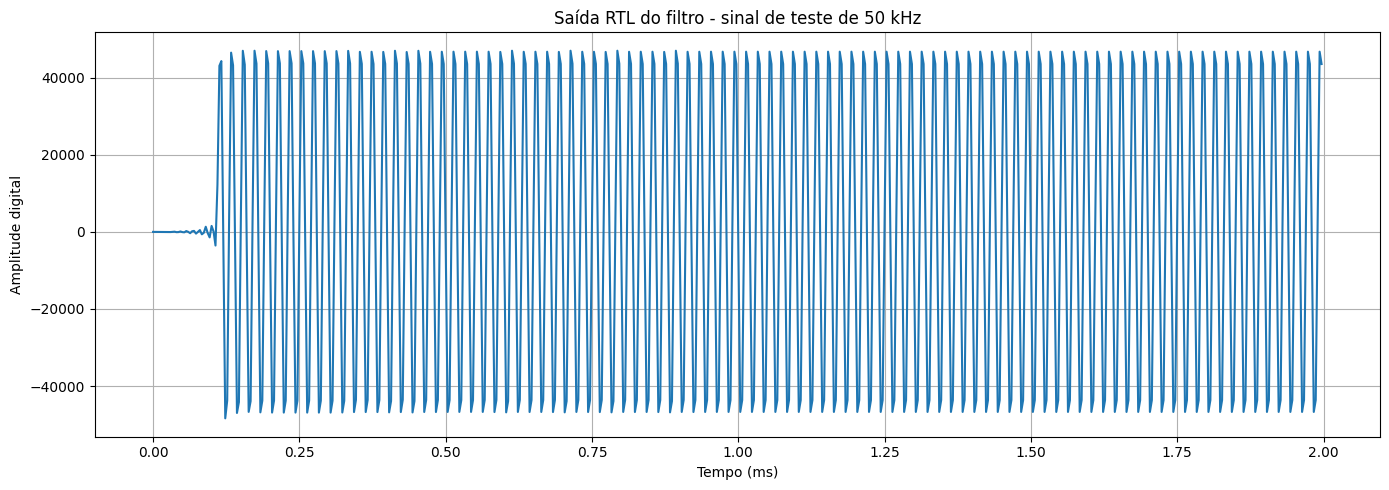

In [ ]:
# ============================================================
# VISUALIZAÇÃO TEMPORAL DA SAÍDA RTL - TESTE 50 kHz
# ============================================================

FS_OUT = 300_000  # Hz

# Eixo de tempo correspondente às 600 amostras de saída
t = np.arange(len(rtl)) / FS_OUT

plt.figure(figsize=(14, 5))

plt.plot(t * 1e3, rtl)

plt.xlabel("Tempo (ms)")
plt.ylabel("Amplitude digital")
plt.title("Saída RTL do filtro - sinal de teste de 50 kHz")

plt.grid(True)
plt.tight_layout()
plt.show()

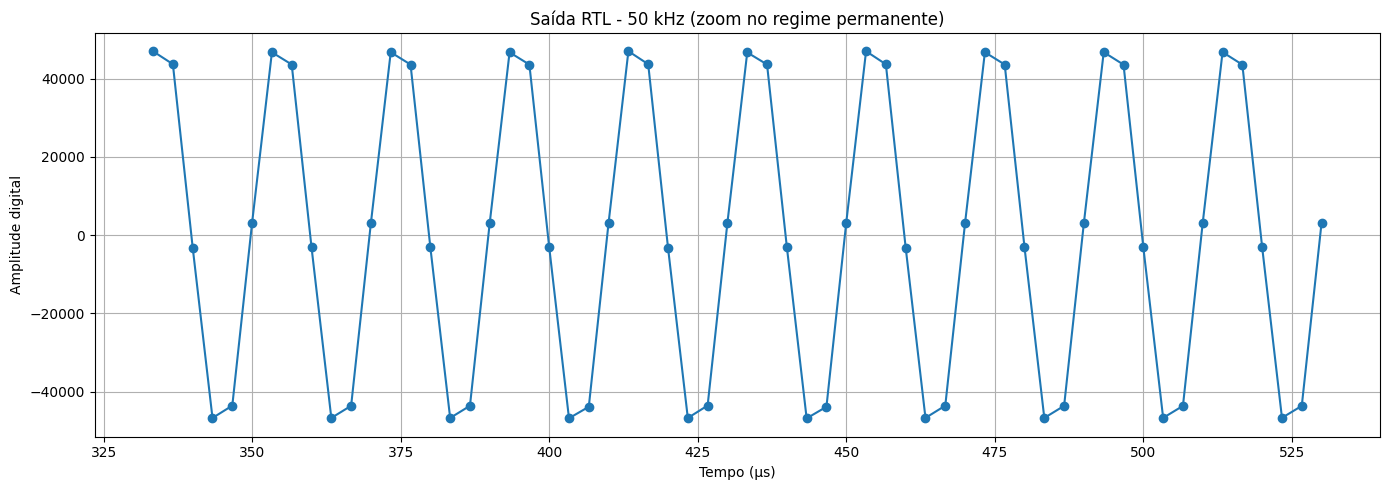

In [ ]:
# ============================================================
# ZOOM TEMPORAL - SAÍDA RTL DE 50 kHz
# ============================================================

# Região já após o transitório
inicio = 100
fim = 160

t_zoom = t[inicio:fim] * 1e6   # segundos -> microssegundos
rtl_zoom = rtl[inicio:fim]

plt.figure(figsize=(14, 5))

plt.plot(
    t_zoom,
    rtl_zoom,
    marker="o"
)

plt.xlabel("Tempo (µs)")
plt.ylabel("Amplitude digital")
plt.title("Saída RTL - 50 kHz (zoom no regime permanente)")

plt.grid(True)
plt.tight_layout()
plt.show()

Número de amostras analisadas : 500
Resolução da FFT              : 600.00 Hz
Frequência do maior pico      : 49.80 kHz


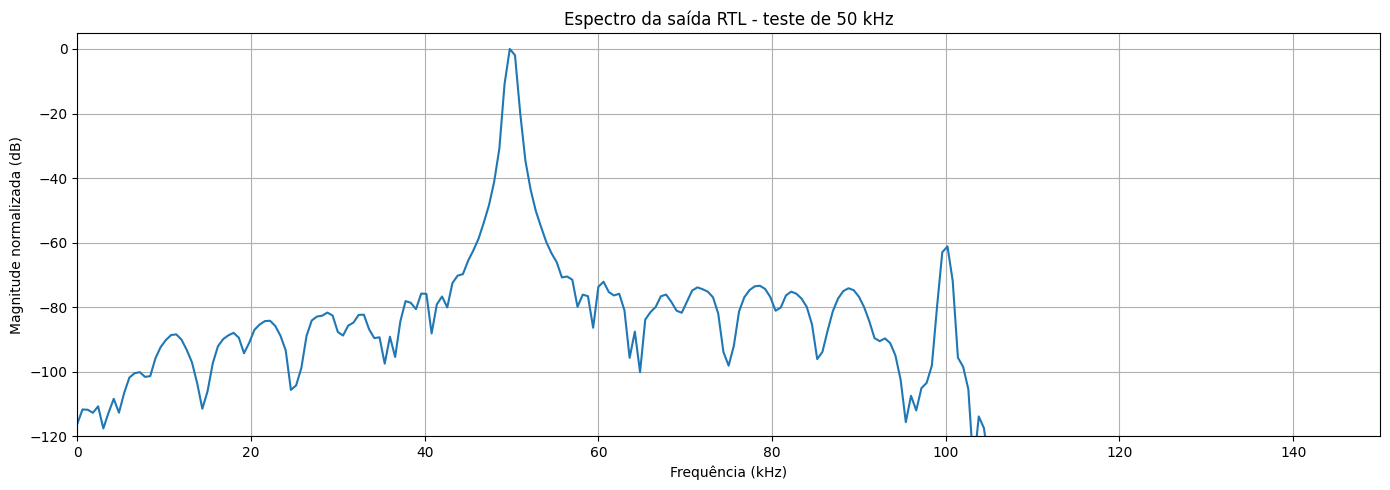

In [ ]:
# ============================================================
# FFT DA SAÍDA RTL - TESTE DE 50 kHz
# ============================================================

FS_OUT = 300_000  # Hz

# Remove o transitório inicial
rtl_fft = rtl[100:]

N = len(rtl_fft)

# Janela de Hann
janela = np.hanning(N)

# FFT real
Y = np.fft.rfft(rtl_fft * janela)

# Eixo de frequências
freq = np.fft.rfftfreq(N, d=1/FS_OUT)

# Magnitude normalizada para facilitar a visualização
magnitude = np.abs(Y)
magnitude = magnitude / np.max(magnitude)

# Converte para dB
magnitude_db = 20 * np.log10(magnitude + 1e-12)

# Ignora DC para procurar a componente dominante
indice_pico = np.argmax(magnitude[1:]) + 1
freq_pico = freq[indice_pico]

print(f"Número de amostras analisadas : {N}")
print(f"Resolução da FFT              : {FS_OUT/N:.2f} Hz")
print(f"Frequência do maior pico      : {freq_pico/1e3:.2f} kHz")

plt.figure(figsize=(14, 5))

plt.plot(freq / 1e3, magnitude_db)

plt.xlabel("Frequência (kHz)")
plt.ylabel("Magnitude normalizada (dB)")
plt.title("Espectro da saída RTL - teste de 50 kHz")

plt.xlim(0, FS_OUT / 2 / 1e3)
plt.ylim(-120, 5)

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test_06_burst_50k_ruido_output_rtl.txt to test_06_burst_50k_ruido_output_rtl.txt


In [ ]:
# ============================================================
# CARREGAMENTO DOS 6 TESTES RTL
# ============================================================

testes_rtl = {
    "10 kHz": np.loadtxt(
        "test_01_10k_output_rtl.txt",
        dtype=np.int64
    ),

    "30 kHz": np.loadtxt(
        "test_02_30k_output_rtl.txt",
        dtype=np.int64
    ),

    "50 kHz": np.loadtxt(
        "test_03_50k_output_rtl.txt",
        dtype=np.int64
    ),

    "80 kHz": np.loadtxt(
        "test_04_80k_output_rtl.txt",
        dtype=np.int64
    ),

    "50 kHz + ruído": np.loadtxt(
        "test_05_50k_ruido_output_rtl.txt",
        dtype=np.int64
    ),

    "Burst 50 kHz + ruído": np.loadtxt(
        "test_06_burst_50k_ruido_output_rtl.txt",
        dtype=np.int64
    )
}

print("TESTES RTL CARREGADOS")
print("=" * 55)

for nome, sinal in testes_rtl.items():
    print(
        f"{nome:22s} | "
        f"N = {len(sinal):3d} | "
        f"min = {np.min(sinal):7d} | "
        f"max = {np.max(sinal):7d}"
    )

TESTES RTL CARREGADOS
10 kHz                 | N = 600 | min =  -52505 | max =   52589
30 kHz                 | N = 600 | min =  -51179 | max =   50699
50 kHz                 | N = 600 | min =  -48389 | max =   47021
80 kHz                 | N = 600 | min =  -53745 | max =   52370
50 kHz + ruído         | N = 600 | min =  -44353 | max =   44383
Burst 50 kHz + ruído   | N = 600 | min =  -42717 | max =   42520


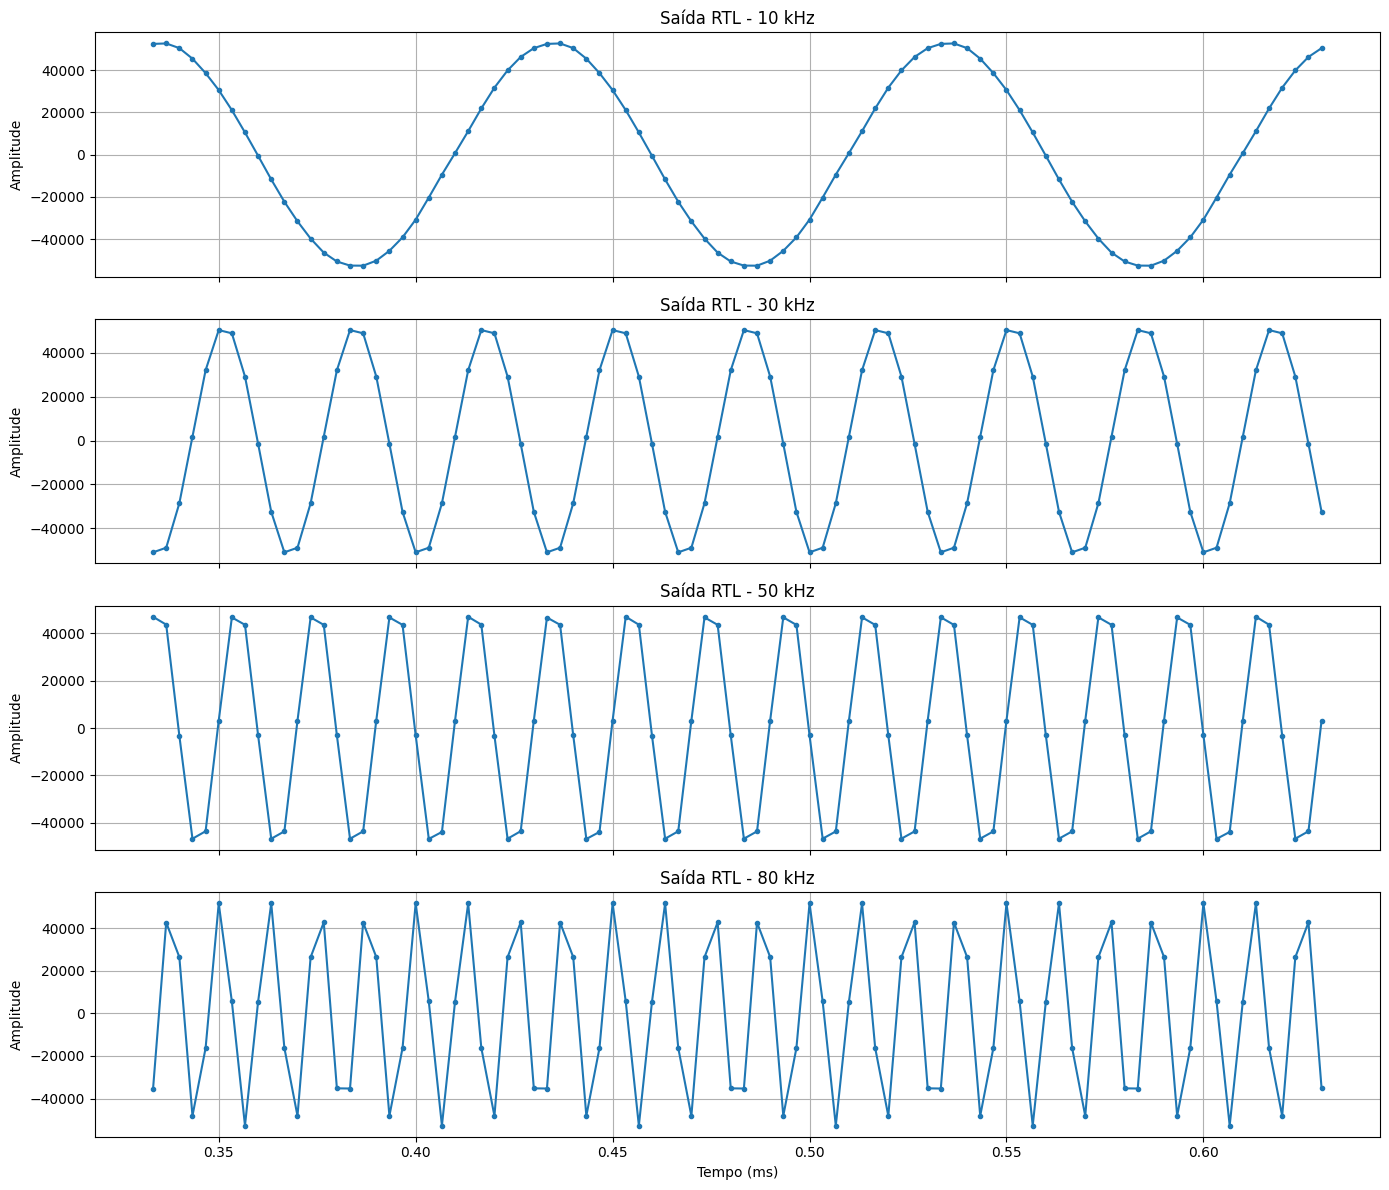

In [ ]:
# ============================================================
# COMPARAÇÃO TEMPORAL DOS 4 TONS PUROS - SAÍDA RTL
# ============================================================

FS_OUT = 300_000  # Hz

# Região após o transitório
inicio = 100
fim = 190

# Eixo de tempo
t_plot = np.arange(inicio, fim) / FS_OUT

tons = [
    ("10 kHz", testes_rtl["10 kHz"]),
    ("30 kHz", testes_rtl["30 kHz"]),
    ("50 kHz", testes_rtl["50 kHz"]),
    ("80 kHz", testes_rtl["80 kHz"])
]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for ax, (nome, sinal) in zip(axes, tons):

    ax.plot(
        t_plot * 1e3,
        sinal[inicio:fim],
        marker="o",
        markersize=3
    )

    ax.set_title(f"Saída RTL - {nome}")
    ax.set_ylabel("Amplitude")
    ax.grid(True)

axes[-1].set_xlabel("Tempo (ms)")

plt.tight_layout()
plt.show()

RESULTADOS DA FFT
10 kHz   -> pico =  10.20 kHz
30 kHz   -> pico =  30.00 kHz
50 kHz   -> pico =  49.80 kHz
80 kHz   -> pico =  79.80 kHz


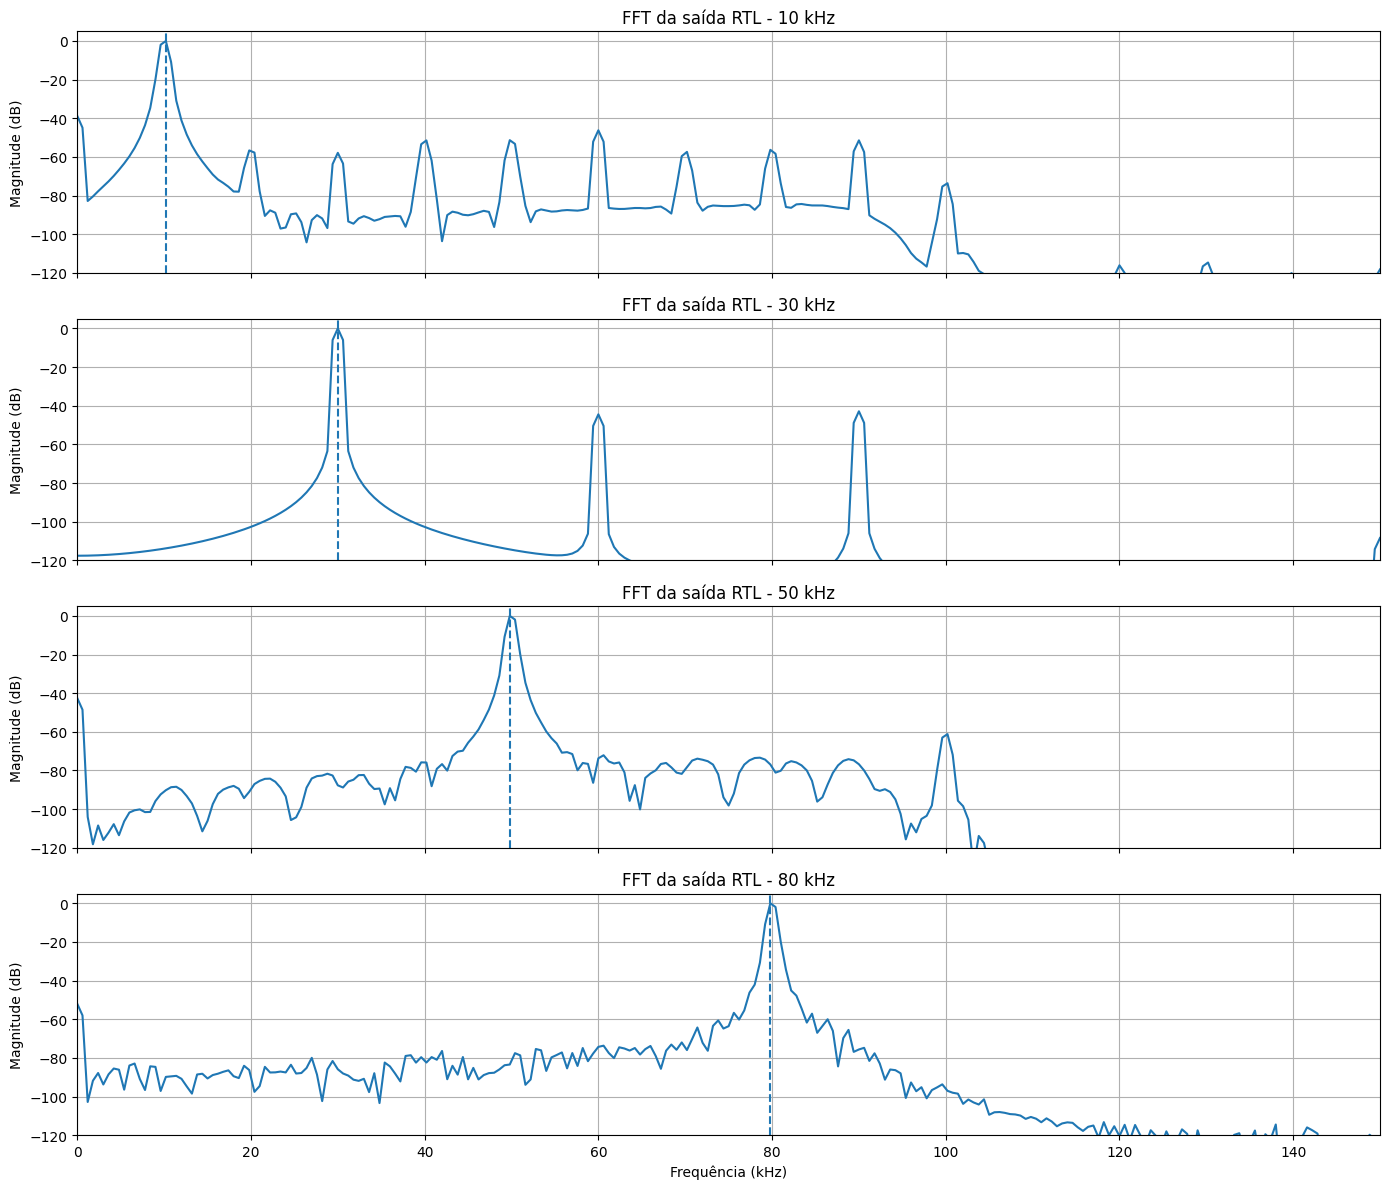

In [ ]:
# ============================================================
# FFT DOS 4 TONS PUROS - SAÍDA RTL
# ============================================================

FS_OUT = 300_000  # Hz

# Remove o transitório inicial
inicio_fft = 100

tons_fft = [
    ("10 kHz", testes_rtl["10 kHz"]),
    ("30 kHz", testes_rtl["30 kHz"]),
    ("50 kHz", testes_rtl["50 kHz"]),
    ("80 kHz", testes_rtl["80 kHz"])
]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

print("RESULTADOS DA FFT")
print("=" * 50)

for ax, (nome, sinal) in zip(axes, tons_fft):

    x = sinal[inicio_fft:]
    N = len(x)

    # Remove eventual componente DC
    x = x - np.mean(x)

    # Janela de Hann
    janela = np.hanning(N)

    # FFT para sinais reais
    Y = np.fft.rfft(x * janela)

    # Frequências correspondentes
    freq = np.fft.rfftfreq(N, d=1/FS_OUT)

    # Magnitude
    mag = np.abs(Y)

    # Normalização
    mag = mag / np.max(mag)

    # Conversão para dB
    mag_db = 20 * np.log10(mag + 1e-12)

    # Localização do maior pico
    indice_pico = np.argmax(mag[1:]) + 1
    freq_pico = freq[indice_pico]

    print(
        f"{nome:8s} -> "
        f"pico = {freq_pico/1e3:6.2f} kHz"
    )

    ax.plot(freq / 1e3, mag_db)

    ax.axvline(
        freq_pico / 1e3,
        linestyle="--"
    )

    ax.set_title(f"FFT da saída RTL - {nome}")
    ax.set_ylabel("Magnitude (dB)")
    ax.set_ylim(-120, 5)
    ax.grid(True)

axes[-1].set_xlabel("Frequência (kHz)")
axes[-1].set_xlim(0, 150)

plt.tight_layout()
plt.show()

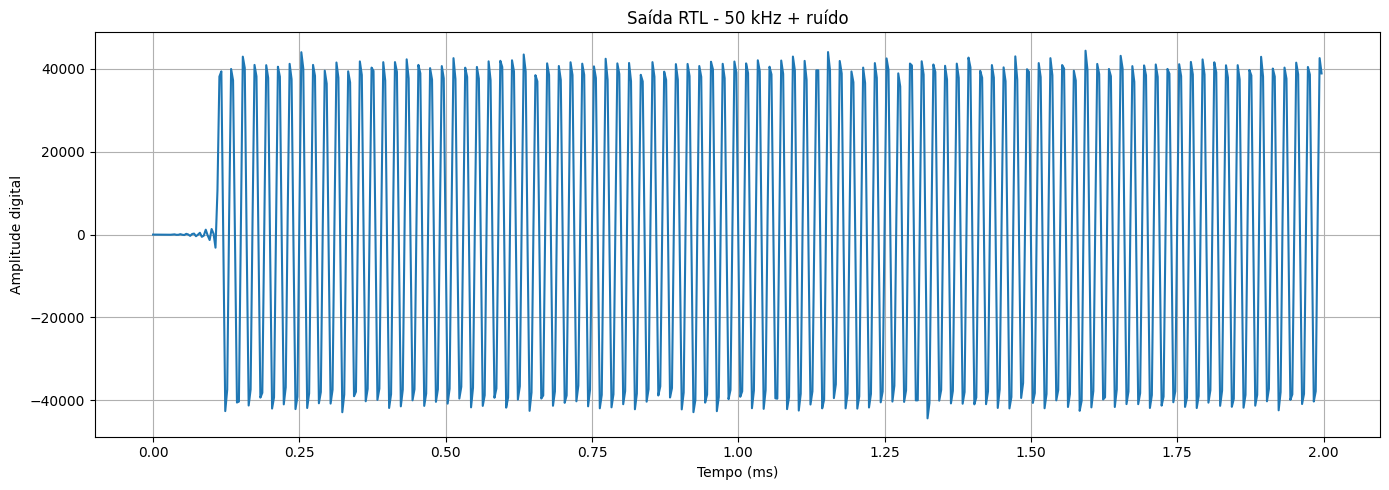

Número de amostras analisadas : 500
Resolução da FFT              : 600.00 Hz
Frequência dominante          : 49.80 kHz


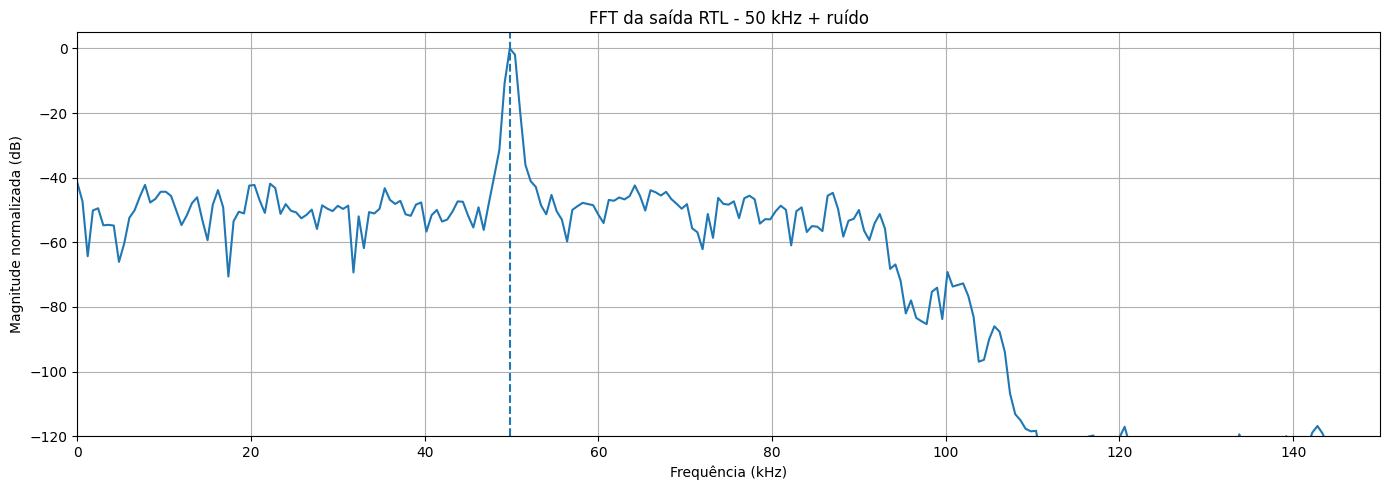

In [ ]:
# ============================================================
# TESTE RTL - 50 kHz + RUÍDO
# Domínio do tempo e frequência
# ============================================================

FS_OUT = 300_000

x_ruido = testes_rtl["50 kHz + ruído"]

# ------------------------------------------------------------
# Domínio do tempo
# ------------------------------------------------------------

t_ruido = np.arange(len(x_ruido)) / FS_OUT

plt.figure(figsize=(14, 5))

plt.plot(t_ruido * 1e3, x_ruido)

plt.xlabel("Tempo (ms)")
plt.ylabel("Amplitude digital")
plt.title("Saída RTL - 50 kHz + ruído")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Domínio da frequência
# ------------------------------------------------------------

# Remove o transitório inicial
x = x_ruido[100:]

N = len(x)

# Remove componente DC
x = x - np.mean(x)

# Janela de Hann
janela = np.hanning(N)

Y = np.fft.rfft(x * janela)

freq = np.fft.rfftfreq(
    N,
    d=1/FS_OUT
)

mag = np.abs(Y)

# Normalização
mag = mag / np.max(mag)

mag_db = 20 * np.log10(
    mag + 1e-12
)

# Pico dominante
indice_pico = np.argmax(mag[1:]) + 1
freq_pico = freq[indice_pico]

print(f"Número de amostras analisadas : {N}")
print(f"Resolução da FFT              : {FS_OUT/N:.2f} Hz")
print(f"Frequência dominante          : {freq_pico/1e3:.2f} kHz")

plt.figure(figsize=(14, 5))

plt.plot(
    freq / 1e3,
    mag_db
)

plt.axvline(
    freq_pico / 1e3,
    linestyle="--"
)

plt.xlabel("Frequência (kHz)")
plt.ylabel("Magnitude normalizada (dB)")
plt.title("FFT da saída RTL - 50 kHz + ruído")

plt.xlim(0, 150)
plt.ylim(-120, 5)

plt.grid(True)
plt.tight_layout()
plt.show()

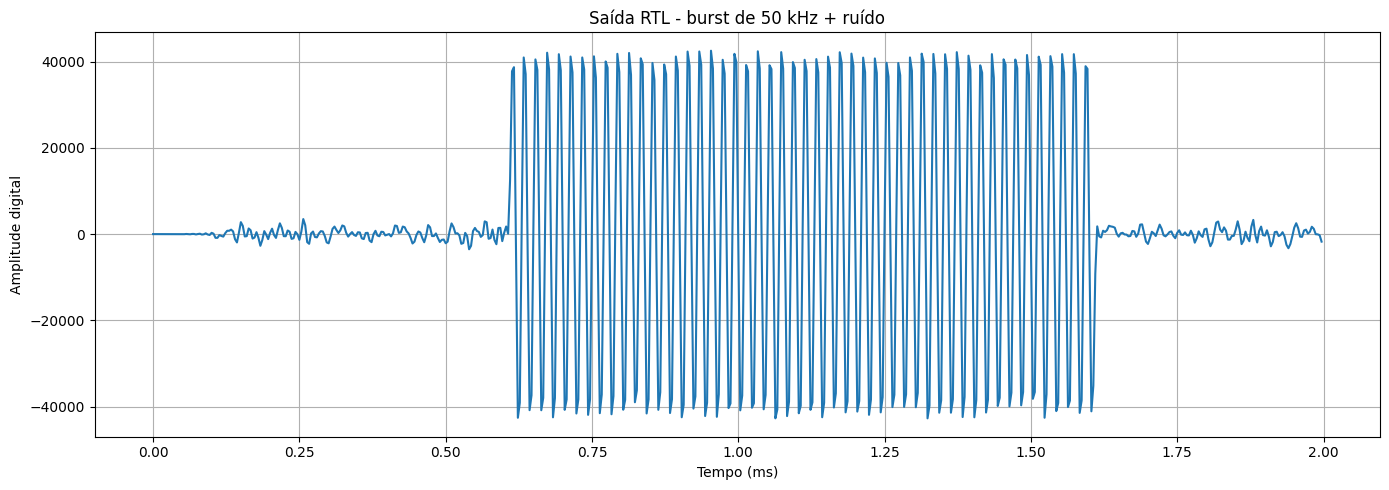

In [ ]:
# ============================================================
# TESTE RTL - BURST DE 50 kHz + RUÍDO
# DOMÍNIO DO TEMPO
# ============================================================

FS_OUT = 300_000

x_burst = testes_rtl["Burst 50 kHz + ruído"]

t_burst = np.arange(len(x_burst)) / FS_OUT

plt.figure(figsize=(14, 5))

plt.plot(
    t_burst * 1e3,
    x_burst
)

plt.xlabel("Tempo (ms)")
plt.ylabel("Amplitude digital")
plt.title("Saída RTL - burst de 50 kHz + ruído")

plt.grid(True)
plt.tight_layout()
plt.show()

Número de amostras       : 600
Resolução da FFT         : 500.00 Hz
Frequência dominante     : 50.00 kHz


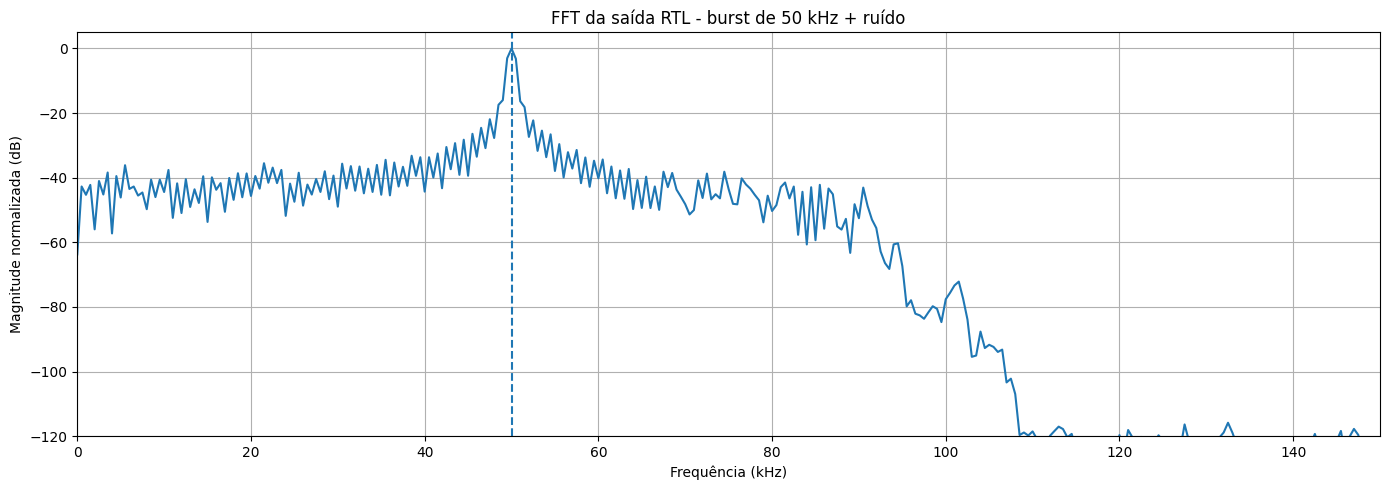

In [ ]:
# ============================================================
# FFT DA SAÍDA RTL - BURST DE 50 kHz + RUÍDO
# ============================================================

FS_OUT = 300_000

x = x_burst.copy()

# Remove componente DC
x = x - np.mean(x)

N = len(x)

# Janela de Hann
janela = np.hanning(N)

# FFT
Y = np.fft.rfft(x * janela)

freq = np.fft.rfftfreq(
    N,
    d=1/FS_OUT
)

mag = np.abs(Y)

# Normalização
mag = mag / np.max(mag)

mag_db = 20 * np.log10(
    mag + 1e-12
)

# Pico dominante
indice_pico = np.argmax(mag[1:]) + 1
freq_pico = freq[indice_pico]

print(f"Número de amostras       : {N}")
print(f"Resolução da FFT         : {FS_OUT/N:.2f} Hz")
print(f"Frequência dominante     : {freq_pico/1e3:.2f} kHz")

plt.figure(figsize=(14, 5))

plt.plot(
    freq / 1e3,
    mag_db
)

plt.axvline(
    freq_pico / 1e3,
    linestyle="--"
)

plt.xlabel("Frequência (kHz)")
plt.ylabel("Magnitude normalizada (dB)")
plt.title("FFT da saída RTL - burst de 50 kHz + ruído")

plt.xlim(0, 150)
plt.ylim(-120, 5)

plt.grid(True)
plt.tight_layout()
plt.show()

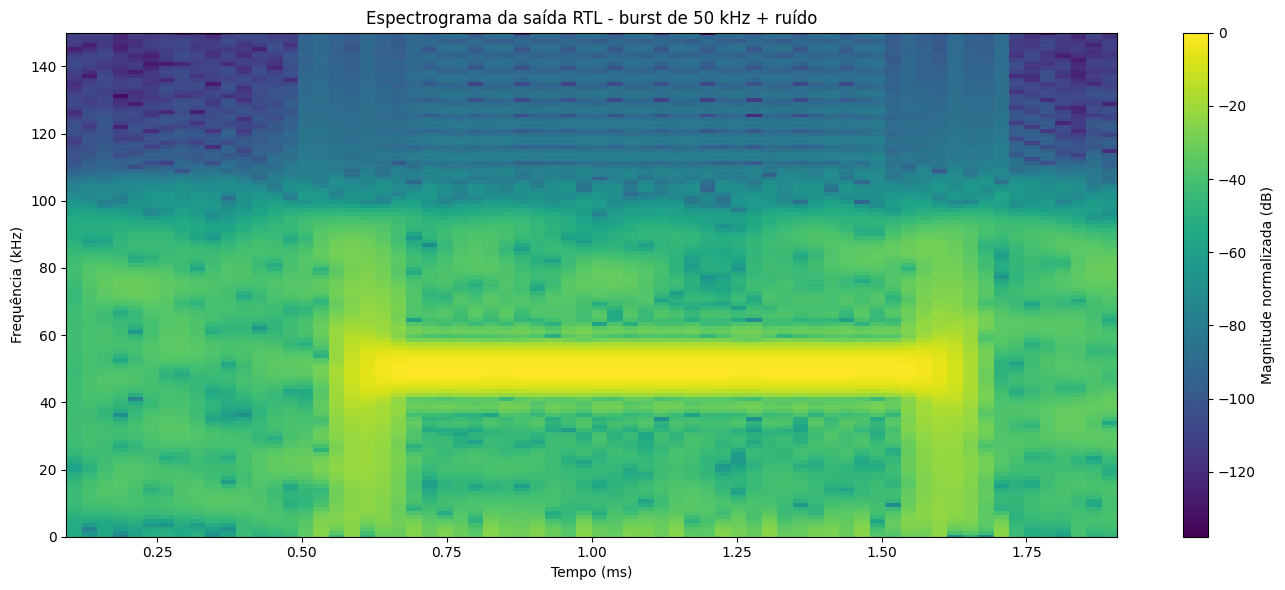

In [ ]:
# ============================================================
# ESPECTROGRAMA DA SAÍDA RTL
# BURST DE 50 kHz + RUÍDO
# ============================================================

FS_OUT = 300_000

x = x_burst.astype(float)

# Remove componente DC
x = x - np.mean(x)

# STFT / espectrograma
f_spec, t_spec, Sxx = signal.spectrogram(
    x,
    fs=FS_OUT,
    window="hann",
    nperseg=64,
    noverlap=56,
    nfft=256,
    scaling="spectrum",
    mode="magnitude"
)

# Converte magnitude para dB
Sxx_db = 20 * np.log10(
    Sxx / np.max(Sxx) + 1e-12
)

plt.figure(figsize=(14, 6))

plt.pcolormesh(
    t_spec * 1e3,     # ms
    f_spec / 1e3,     # kHz
    Sxx_db,
    shading="auto"
)

plt.colorbar(
    label="Magnitude normalizada (dB)"
)

plt.xlabel("Tempo (ms)")
plt.ylabel("Frequência (kHz)")
plt.title(
    "Espectrograma da saída RTL - burst de 50 kHz + ruído"
)

plt.ylim(0, 150)

plt.tight_layout()
plt.show()